1. Four-Model Φt Paths

TB=51  TA=54  TD=56  TC=63
Order ok: True


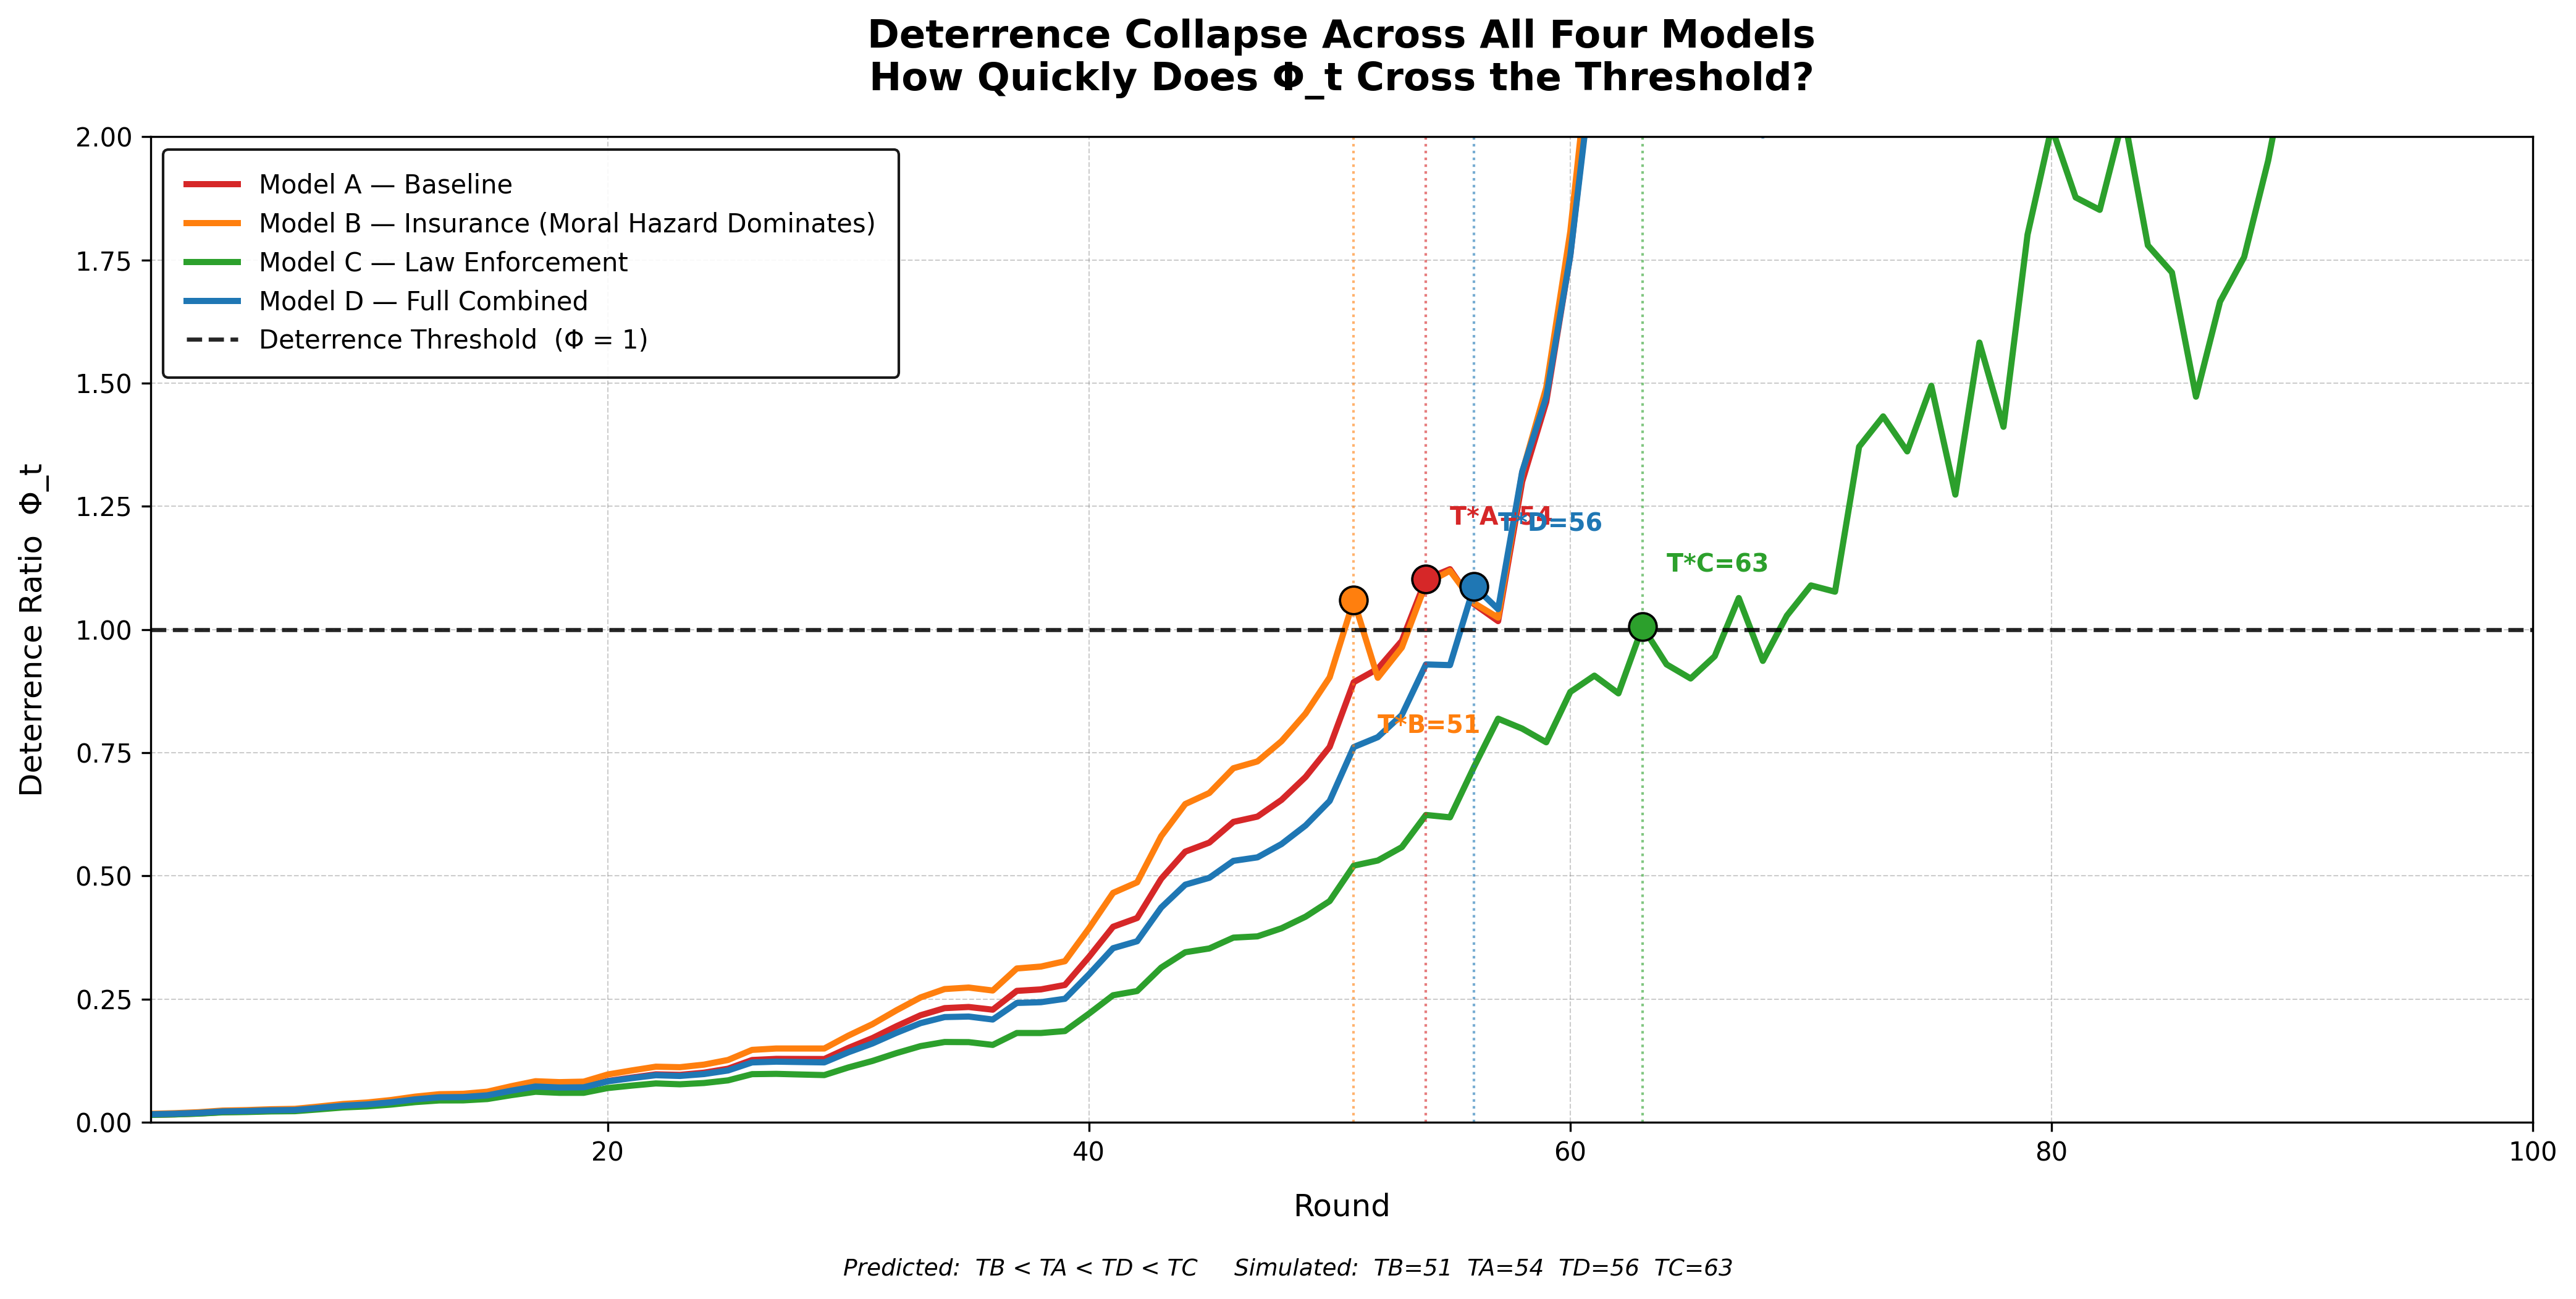

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
T = 100
alpha = 0.8
delta = 0.5
D0 = 5.0
CB0 = 1.0
eps0 = 0.28
kappa_eps = 0.10
kappa_b = 0.8
beta = 0.9
F = 5.0
L = 12.0
CA = 1.5
CD = 3.0
G = 100
xi = 0.5
beta_s = 0.7
M = 25.0
delta_e = 0.15
delta_f = 0.1
kappa_h = 0.25
Cs = 0.8

params = {
'A': dict(mu_a=0.055, mu_n=0.030, lambda0=0.0,  kl=0.25, MH=0.0,  xi_v=0.0),
'B': dict(mu_a=0.055, mu_n=0.020, lambda0=0.0,  kl=0.25, MH=0.25, xi_v=xi),
'C': dict(mu_a=0.044, mu_n=0.033, lambda0=0.65, kl=0.20, MH=0.0,  xi_v=0.0),
'D': dict(mu_a=0.050, mu_n=0.026, lambda0=0.55, kl=0.22, MH=0.12, xi_v=xi),
}

def lr(Aa, An, t):
    return 1 / (1 + (Aa / max(An, 1e-9)) * t), 1 / (1 + (An / max(Aa, 1e-9)) * t)

def S(Aa):
    h = 1 - (delta_f**0.5) / (1 + kappa_h * Aa)
    return max(0, (1 - delta_e) * h * M - Cs)

def fp(Aa, An, eps, Psi, xiv):
    Dt = D0 / (1 + alpha * Aa)
    CBt = CB0 / (1 + delta * An)
    St = S(Aa)
    eL = (1 - xiv) * L
    b = max(np.sqrt(beta * (F + eps * eL) / max(CBt, 1e-9)), 1e-6)
    r = eps * eL / b
    a = max((G * Dt / CA) * (Psi * r + beta_s * St) - Dt, 0)
    Vj = (a * (1 + alpha * Aa)) / (D0 + a * (1 + alpha * Aa) + 1e-9)
    num = Psi * L * eps * a * G
    den = (Dt + a) * (CA * a + CD) + 1e-9
    return (num / den) * np.sqrt(CBt / max(beta * F, 1e-9)), Vj

def run_model(mode, seed=42):
    p = params[mode]
    Aa = An = 1.0
    Ph = []
    sc = 0.0
    np.random.seed(seed)
    for t in range(1, T + 1):
        ra = np.random.uniform(-0.12, 0.12)
        rn = np.random.uniform(-0.12, 0.12)
        CBt = CB0 / (1 + delta * An)
        ba = np.sqrt(beta * F / max(CBt, 1e-9))
        be = eps0 * (1 + kappa_eps * Aa) / (1 + kappa_b * ba)
        xiv = p['xi_v']
        et = be * (1 + p['MH'] * xiv)
        Psi = 1.0
        if p['lambda0'] > 0:
            sr = sc / max(t, 1)
            lam = min(p['lambda0'] * sr / (1 + p['kl'] * Aa), 0.95)
            Psi = 1 - lam
        Phi, Vj = fp(Aa, An, et, Psi, xiv)
        Ph.append(Phi)
        det = Phi < 1
        sop = 0 if det else 1
        fop = 1 - sop
        sc = (sc * (t - 1) + (Vj if not det else 0)) / t
        ea, en = lr(Aa, An, t)
        Aa = Aa * (1 + p['mu_a']) * (1 + ea) * (1 + ra * sop)
        An = An * (1 + p['mu_n']) * (1 + en) * (1 + rn * fop)
    return np.array(Ph)

phi_A = run_model('A')
phi_B = run_model('B')
phi_C = run_model('C')
phi_D = run_model('D')

def fc(phi):
    for i, v in enumerate(phi):
        if v >= 1: return i + 1
    return None

T_A = fc(phi_A)
T_B = fc(phi_B)
T_C = fc(phi_C)
T_D = fc(phi_D)

print(f"TB={T_B}  TA={T_A}  TD={T_D}  TC={T_C}")
print("Order ok:", T_B is not None and T_A and T_D and T_C and T_B < T_A < T_D < T_C)

rounds = np.arange(1, T + 1)
fig, ax = plt.subplots(figsize=(14, 7), dpi=300)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
colors = {'A': '#d62728', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#1f77b4'}

for sp in ax.spines.values():
    sp.set_edgecolor('black')
ax.grid(color='gray', lw=0.5, ls='--', alpha=0.4)
ax.set_axisbelow(True)

ax.plot(rounds, phi_A, color=colors['A'], lw=2.4, label='Model A — Baseline')
ax.plot(rounds, phi_B, color=colors['B'], lw=2.4, label='Model B — Insurance (Moral Hazard Dominates)')
ax.plot(rounds, phi_C, color=colors['C'], lw=2.4, label='Model C — Law Enforcement')
ax.plot(rounds, phi_D, color=colors['D'], lw=2.4, label='Model D — Full Combined')
ax.axhline(1.0, color='black', lw=1.6, ls='--', alpha=0.85, label='Deterrence Threshold  (Φ = 1)')

lbl_dy = {'A': 0.10, 'B': -0.28, 'C': 0.10, 'D': 0.10}
for phi, key in [(phi_A, 'A'), (phi_B, 'B'), (phi_C, 'C'), (phi_D, 'D')]:
    ts = fc(phi)
    if ts:
        ax.axvline(ts, color=colors[key], lw=1.0, ls=':', alpha=0.6)
        ax.scatter([ts], [phi[ts - 1]], color=colors[key], s=115, zorder=6, edgecolors='black', lw=0.9)
        ax.text(ts + 1, phi[ts - 1] + lbl_dy[key], f'T*\u200b{key}={ts}',
                color=colors[key], fontsize=9.5, fontweight='bold', va='bottom')

ax.set_xlabel('Round', color='black', fontsize=12, labelpad=10)
ax.set_ylabel('Deterrence Ratio  Φ_t', color='black', fontsize=12, labelpad=10)
ax.set_title('Deterrence Collapse Across All Four Models\nHow Quickly Does Φ_t Cross the Threshold?',
             color='black', fontsize=15, fontweight='bold', pad=18)
ax.tick_params(colors='black', labelsize=10)
ax.legend(loc='upper left', framealpha=0.9, facecolor='white',
          edgecolor='black', labelcolor='black', fontsize=10, borderpad=0.9)
ax.set_xlim(1, T)
ax.set_ylim(bottom=0, top=2.0)

order_str = (f"Predicted:  TB < TA < TD < TC     "
             f"Simulated:  TB={T_B}  TA={T_A}  TD={T_D}  TC={T_C}")
fig.text(0.5, 0.01, order_str, ha='center', color='black', fontsize=9, style='italic')
plt.tight_layout(rect=[0, 0.03, 1, 1])

plt.show()

2. Heatmap of T
∗
D Over (ξ, λ0)


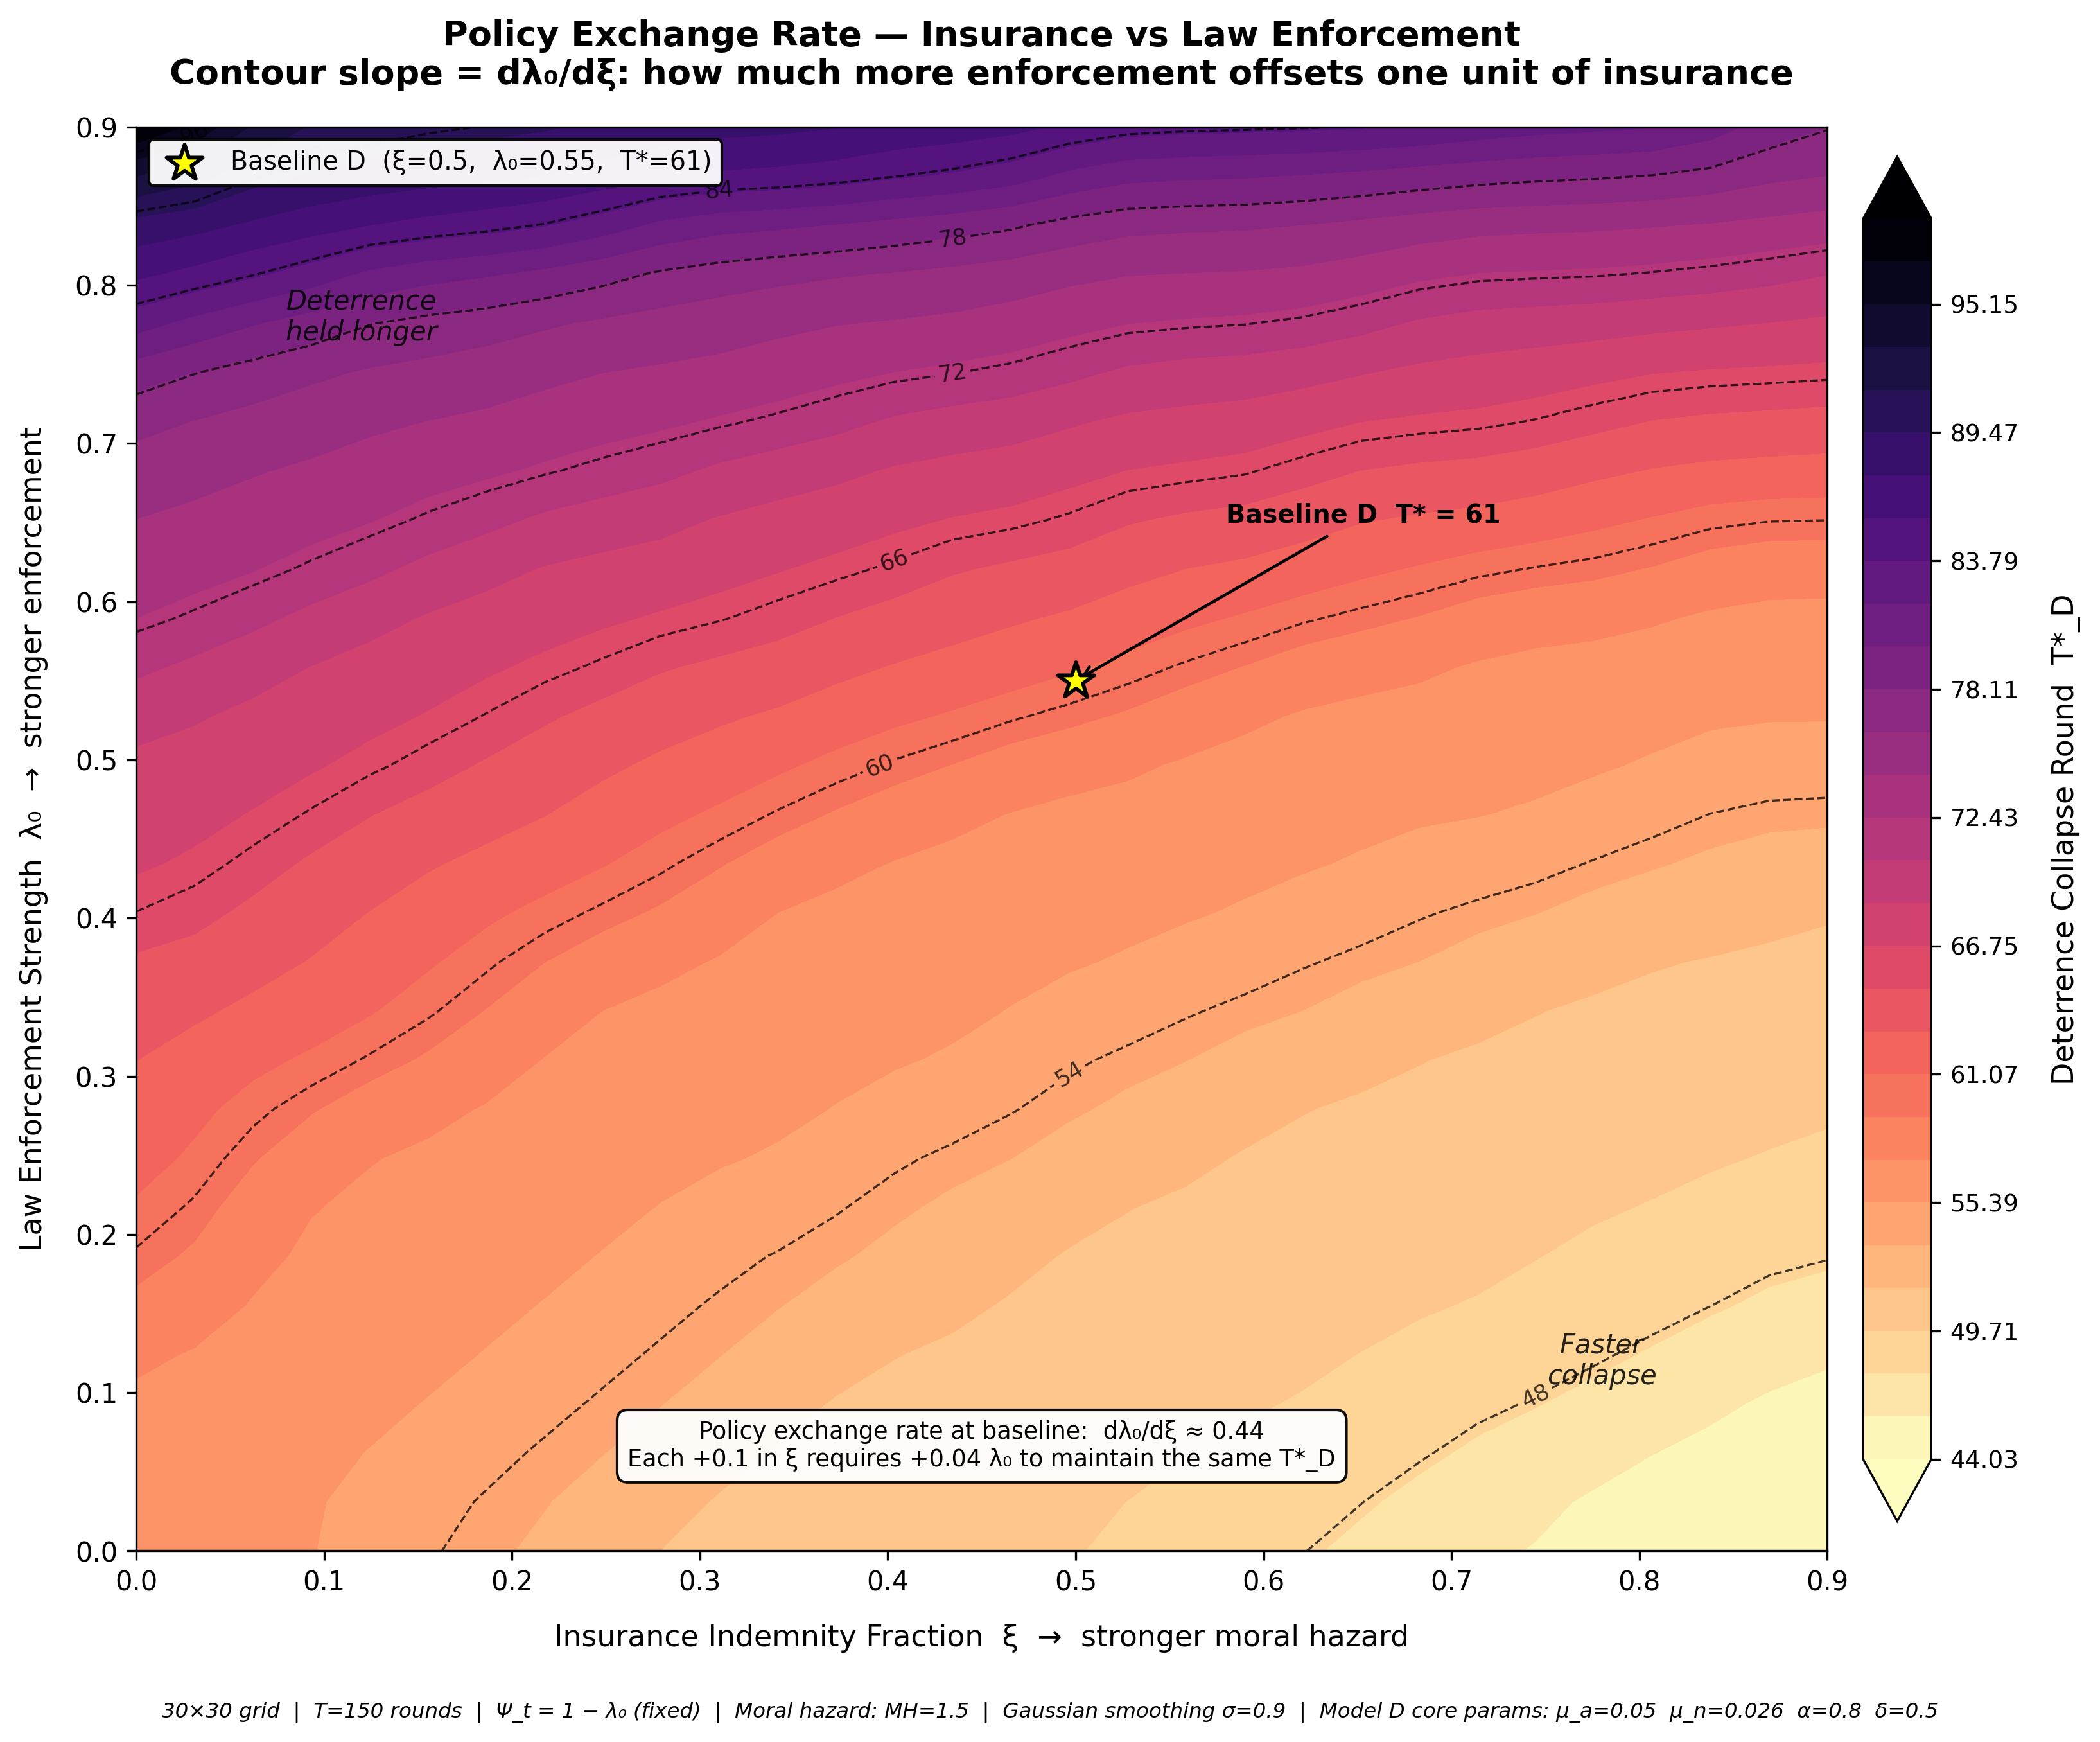

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

np.random.seed(42)

T         = 150
alpha     = 0.8;  delta     = 0.5
D0        = 5.0;  CB0       = 1.0
eps0      = 0.28; kappa_eps = 0.10; kappa_b = 0.8
beta      = 0.9;  F         = 5.0;  L       = 12.0
CA        = 1.5;  CD        = 3.0;  G       = 100
beta_s    = 0.7;  M         = 25.0
delta_e   = 0.15; delta_f   = 0.1;  kappa_h = 0.25; Cs = 0.8
MH        = 1.5
mu_a      = 0.050
mu_n_base = 0.026

def lr(Aa, An, t):
    return 1/(1+(Aa/max(An,1e-9))*t), 1/(1+(An/max(Aa,1e-9))*t)

def S(Aa):
    h = 1-(delta_f**0.5)/(1+kappa_h*Aa)
    return max(0,(1-delta_e)*h*M-Cs)

def fp(Aa, An, eps, Psi, xiv):
    Dt  = D0/(1+alpha*Aa)
    CBt = CB0/(1+delta*An)
    St  = S(Aa)
    eL  = (1-xiv)*L
    b   = max(np.sqrt(beta*(F+eps*eL)/max(CBt,1e-9)), 1e-6)
    r   = eps*eL/b
    a   = max((G*Dt/CA)*(Psi*r+beta_s*St)-Dt, 0)
    Vj  = (a*(1+alpha*Aa))/(D0+a*(1+alpha*Aa)+1e-9)
    num = Psi*L*eps*a*G
    den = (Dt+a)*(CA*a+CD)+1e-9
    return (num/den)*np.sqrt(CBt/max(beta*F,1e-9)), Vj

def run_model_D(xi_val, lam0_val, seed=42):
    Aa = An = 1.0
    Ph = []
    np.random.seed(seed)
    for t in range(1, T+1):
        ra = np.random.uniform(-0.12, 0.12)
        rn = np.random.uniform(-0.12, 0.12)
        CBt = CB0/(1+delta*An)
        ba  = np.sqrt(beta*F/max(CBt,1e-9))
        be  = eps0*(1+kappa_eps*Aa)/(1+kappa_b*ba)
        et  = be*(1+MH*xi_val)
        Psi = 1.0 - lam0_val
        Phi, Vj = fp(Aa, An, et, Psi, xi_val)
        Ph.append(Phi)
        det = Phi < 1.0
        sop = 0.0 if det else 1.0
        fop = 1.0 - sop
        ea, en = lr(Aa, An, t)
        Aa = Aa*(1+mu_a)    *(1+ea)*(1+ra*sop)
        An = An*(1+mu_n_base)*(1+en)*(1+rn*fop)
    return np.array(Ph)

def fc(phi):
    for i, v in enumerate(phi):
        if v >= 1: return i+1
    return T

N        = 30
xi_vals  = np.linspace(0.0, 0.9, N)
lam_vals = np.linspace(0.0, 0.9, N)

TD_matrix = np.zeros((N, N))
total = N*N; done = 0
for i, lam in enumerate(lam_vals):
    for j, xi in enumerate(xi_vals):
        TD_matrix[i, j] = fc(run_model_D(xi, lam))
        done += 1

TD_sm = gaussian_filter(TD_matrix, sigma=0.9)
X, Y  = np.meshgrid(xi_vals, lam_vals)

BASE_XI  = 0.5
BASE_LAM = 0.55
i_base   = int(np.argmin(np.abs(lam_vals - BASE_LAM)))
j_base   = int(np.argmin(np.abs(xi_vals  - BASE_XI)))
t_base   = int(TD_matrix[i_base, j_base])

slope_xi  = np.gradient(TD_sm, xi_vals,  axis=1)
slope_lam = np.gradient(TD_sm, lam_vals, axis=0)
exch      = -slope_xi / (slope_lam + 1e-9)
exch_base = exch[i_base, j_base]

fig, ax = plt.subplots(figsize=(11, 9), dpi=300)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
for sp in ax.spines.values(): sp.set_edgecolor('black')

n_levels = 30
levels   = np.linspace(TD_sm.min(), TD_sm.max(), n_levels)
cf = ax.contourf(X, Y, TD_sm, levels=levels, cmap='magma_r', extend='both')

raw_range = TD_sm.max() - TD_sm.min()
step = max(3, int(raw_range // 9))
contour_ticks = np.arange(
    int(np.ceil(TD_sm.min()/step)*step),
    int(TD_sm.max())+1, step
)
cl = ax.contour(X, Y, TD_sm, levels=contour_ticks,
                colors='black', linewidths=0.80, alpha=0.75, linestyles='--')
ax.clabel(cl, inline=True, fontsize=8.5, fmt='%d',
          colors='black', inline_spacing=5)

ax.scatter([BASE_XI], [BASE_LAM], color='yellow', s=200, zorder=8,
           marker='*', edgecolors='black', linewidths=1.4,
           label=f'Baseline D  (ξ={BASE_XI},  λ₀={BASE_LAM},  T*={t_base})')
ax.annotate(f'Baseline D  T* = {t_base}',
            xy=(BASE_XI, BASE_LAM),
            xytext=(BASE_XI+0.08, BASE_LAM+0.10),
            color='black', fontsize=9.5, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.1))

ax.text(0.45, 0.05,
        f'Policy exchange rate at baseline:  dλ₀/dξ ≈ {exch_base:.2f}\n'
        f'Each +0.1 in ξ requires +{exch_base*0.1:.2f} λ₀ to maintain the same T*_D',
        color='black', fontsize=8.8, ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.45', facecolor='white',
                  edgecolor='black', alpha=0.95))

ax.text(0.12, 0.78, 'Deterrence\nheld longer', color='black',
        fontsize=10, ha='center', va='center', style='italic', alpha=0.85)
ax.text(0.78, 0.12, 'Faster\ncollapse', color='black',
        fontsize=10, ha='center', va='center', style='italic', alpha=0.85)

cbar = fig.colorbar(cf, ax=ax, fraction=0.038, pad=0.02)
cbar.set_label('Deterrence Collapse Round  T*_D',
               color='black', fontsize=11, labelpad=12)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black', fontsize=9)
cbar.ax.set_facecolor('white')
cbar.outline.set_edgecolor('black')

ax.set_xlabel('Insurance Indemnity Fraction  ξ  →  stronger moral hazard',
              color='black', fontsize=11, labelpad=10)
ax.set_ylabel('Law Enforcement Strength  λ₀  →  stronger enforcement',
              color='black', fontsize=11, labelpad=10)
ax.set_title(
    'Policy Exchange Rate — Insurance vs Law Enforcement\n'
    'Contour slope = dλ₀/dξ: how much more enforcement offsets one unit of insurance',
    color='black', fontsize=13, fontweight='bold', pad=16
)
ax.tick_params(colors='black', labelsize=10)
ax.legend(loc='upper left', framealpha=0.95, facecolor='white',
          edgecolor='black', labelcolor='black', fontsize=9.5)

note = (f'{N}×{N} grid  |  T={T} rounds  |  Ψ_t = 1 − λ₀ (fixed)  |  '
        f'Moral hazard: MH={MH}  |  Gaussian smoothing σ=0.9  |  '
        f'Model D core params: μ_a={mu_a}  μ_n={mu_n_base}  α={alpha}  δ={delta}')
fig.text(0.5, 0.004, note, ha='center', color='black', fontsize=7.8, style='italic')

plt.tight_layout(rect=[0, 0.025, 1, 1])
plt.show()

3. Data-Selling Floor


C floor: 27.0042   D floor: 27.0042
Difference: 0.000000
C range: 27.004 — 31.475
D range: 27.004 — 29.520


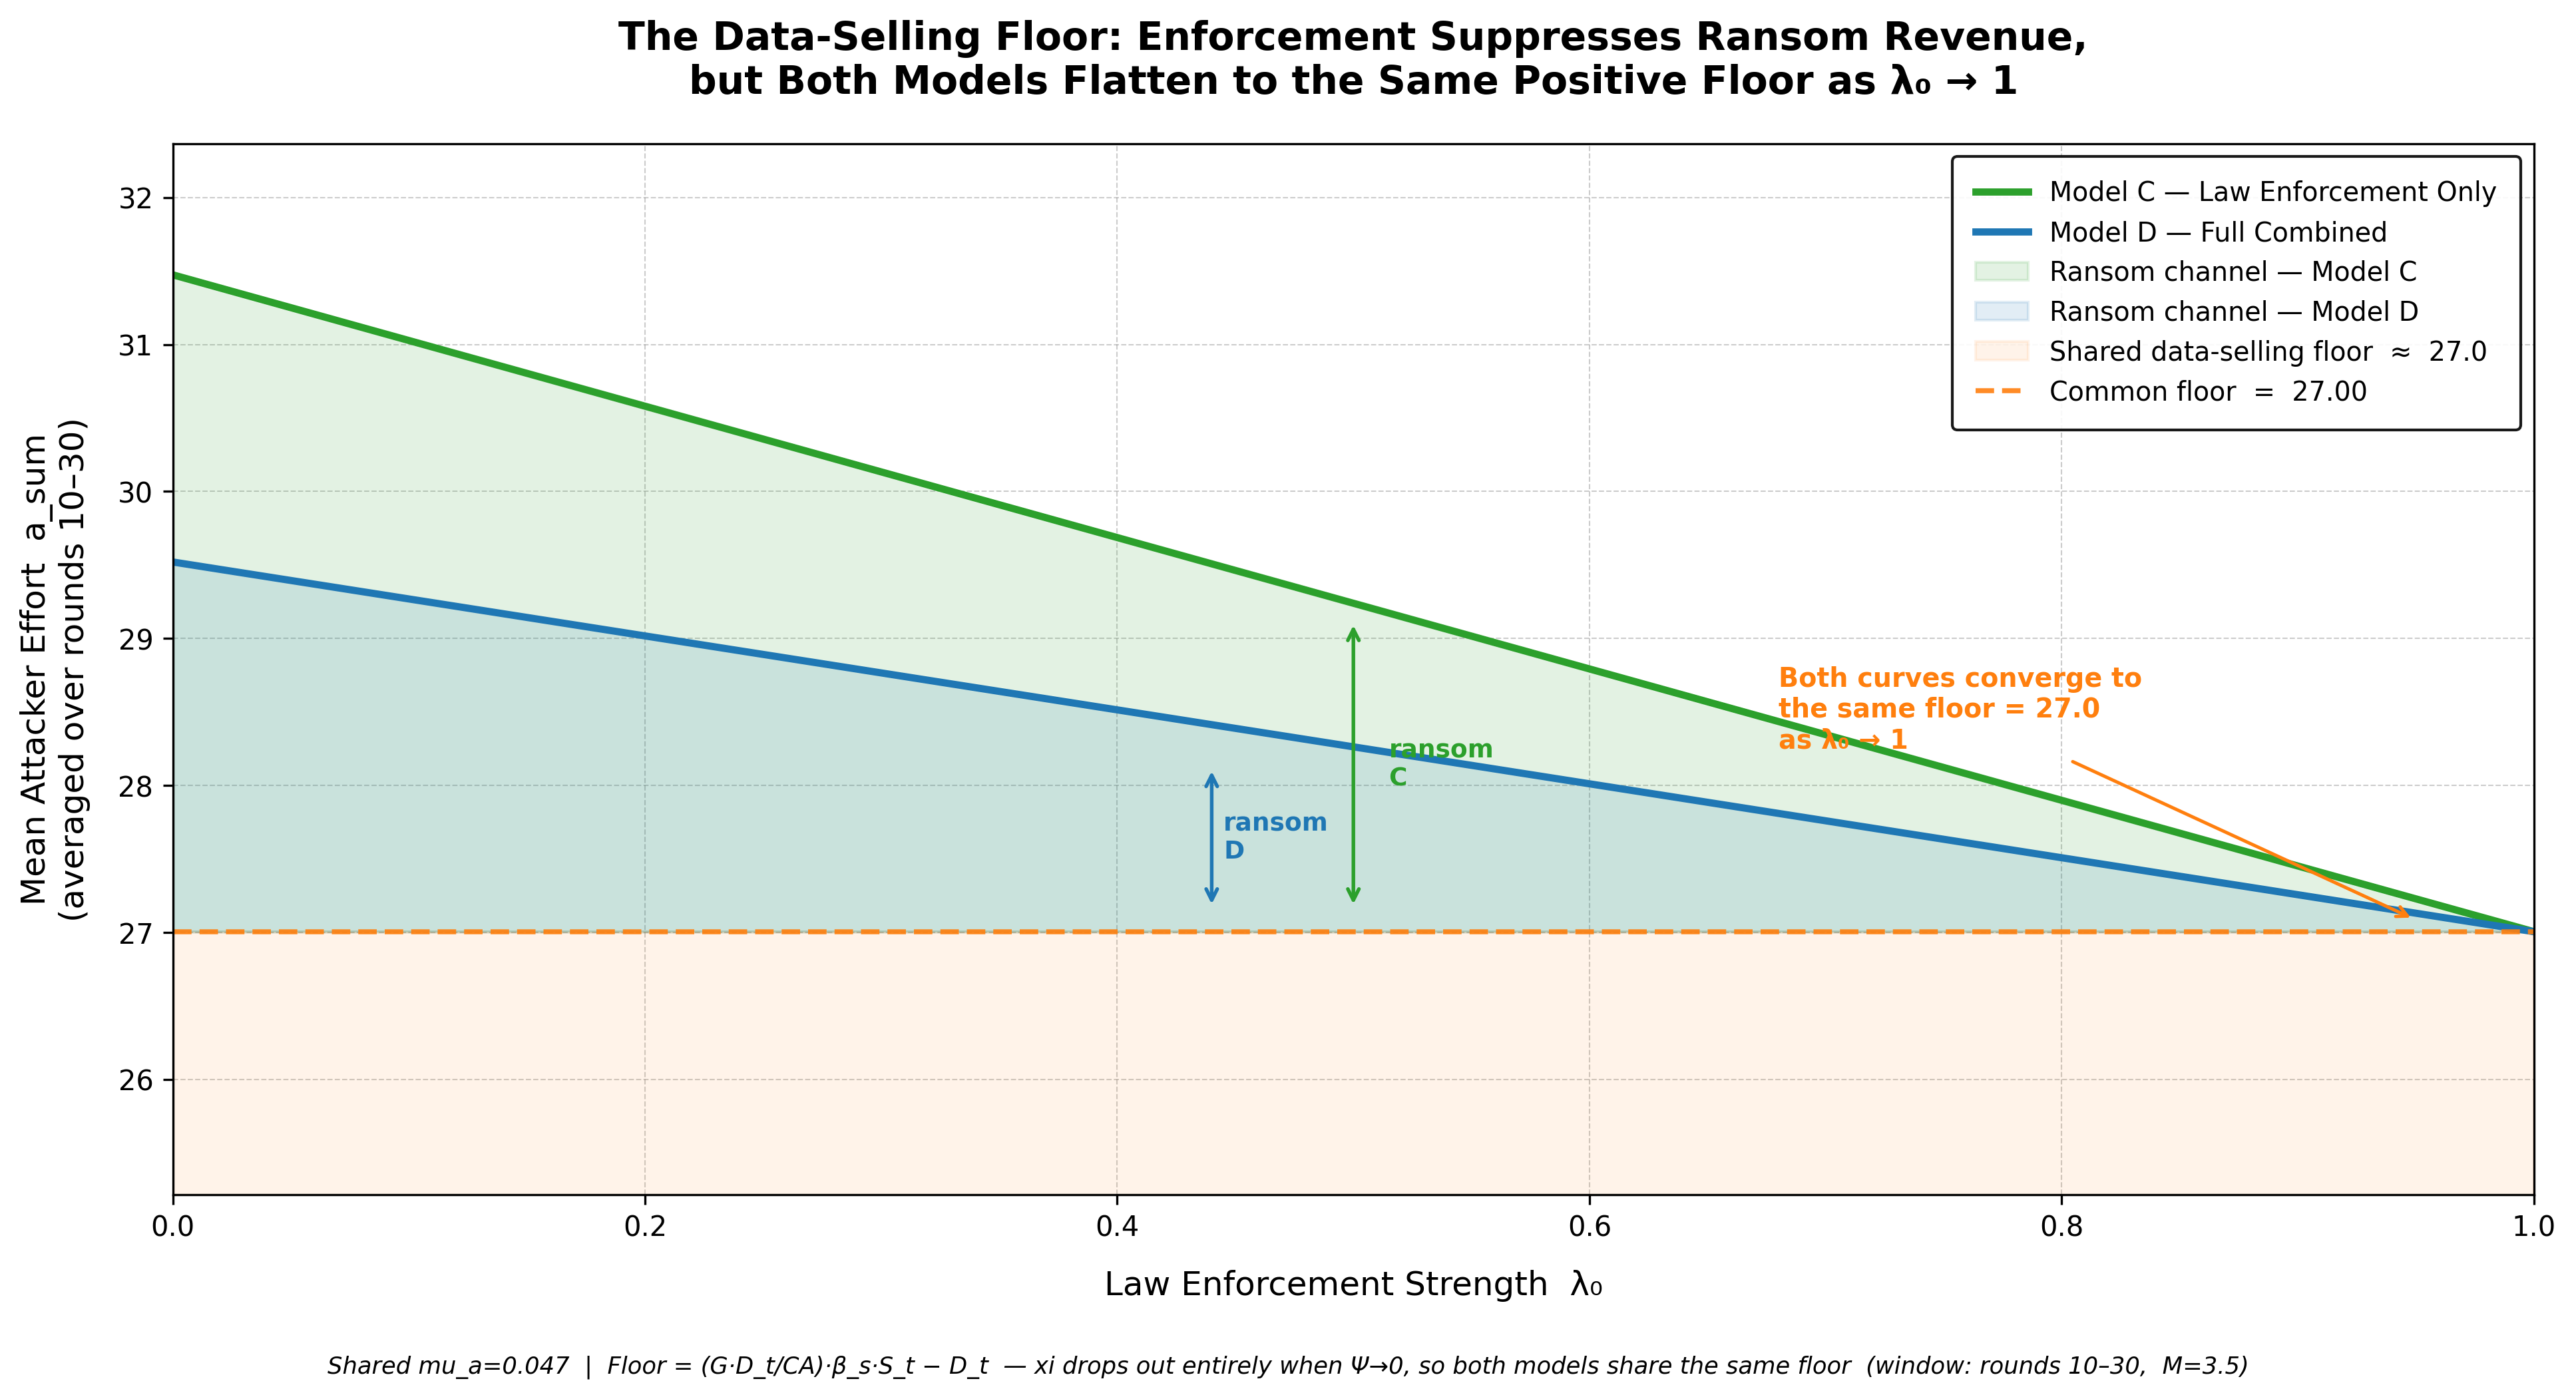

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

T = 100
alpha=0.8; delta=0.5; D0=5.0; CB0=1.0
eps0=0.28; kappa_eps=0.10; kappa_b=0.8
beta=0.9; F=5.0; L=12.0; CA=1.5; CD=3.0; G=100
xi=0.5; beta_s=0.7; Cs=0.8
delta_e=0.15; delta_f=0.1; kappa_h=0.25; M=3.5

MU_A_SHARED = 0.047
MU_N_SHARED = 0.030

params = {
    'C': dict(MH=0.0,  xi_v=0.0),
    'D': dict(MH=0.12, xi_v=xi),
}

WINDOW_START = 10
WINDOW_END   = 30

def lr(Aa, An, t):
    return 1/(1+(Aa/max(An,1e-9))*t), 1/(1+(An/max(Aa,1e-9))*t)

def S(Aa):
    h = 1-(delta_f**0.5)/(1+kappa_h*Aa)
    return max(0,(1-delta_e)*h*M-Cs)

def fp(Aa, An, eps, Psi, xiv):
    Dt  = D0/(1+alpha*Aa)
    CBt = CB0/(1+delta*An)
    St  = S(Aa)
    eL  = (1-xiv)*L
    b   = max(np.sqrt(beta*(F+eps*eL)/max(CBt,1e-9)), 1e-6)
    r   = eps*eL/b
    a_total = max((G*Dt/CA)*(Psi*r + beta_s*St) - Dt, 0)
    a_floor = max((G*Dt/CA)*(beta_s*St) - Dt, 0)
    Vj  = (a_total*(1+alpha*Aa))/(D0+a_total*(1+alpha*Aa)+1e-9)
    num = Psi*L*eps*a_total*G
    den = (Dt+a_total)*(CA*a_total+CD)+1e-9
    Phi = (num/den)*np.sqrt(CBt/max(beta*F,1e-9))
    return Phi, Vj, a_total, a_floor

def run_model_l0(mode, lambda0, seed=42):
    p  = params[mode]
    Aa = An = 1.0
    sc = 0.0
    win_total = []
    win_floor = []
    np.random.seed(seed)
    for t in range(1, T+1):
        ra = np.random.uniform(-0.12, 0.12)
        rn = np.random.uniform(-0.12, 0.12)
        CBt = CB0/(1+delta*An)
        ba  = np.sqrt(beta*F/max(CBt, 1e-9))
        be  = eps0*(1+kappa_eps*Aa)/(1+kappa_b*ba)
        xiv = p['xi_v']
        et  = be*(1+p['MH']*xiv)
        Psi = 1.0 - lambda0
        Phi, Vj, a_total, a_floor = fp(Aa, An, et, Psi, xiv)
        if WINDOW_START <= t <= WINDOW_END:
            win_total.append(a_total)
            win_floor.append(a_floor)
        det = Phi < 1.0
        sop = 0.0 if det else 1.0
        fop = 1.0 - sop
        sc  = (sc*(t-1) + (Vj if not det else 0.0)) / t
        ea, en = lr(Aa, An, t)
        Aa = Aa*(1+MU_A_SHARED)*(1+ea)*(1+ra*sop)
        An = An*(1+MU_N_SHARED)*(1+en)*(1+rn*fop)
    return (np.mean(win_total) if win_total else 0.0,
            np.mean(win_floor)  if win_floor  else 0.0)

lambda_grid = np.linspace(0, 1, 60)

res_C = [run_model_l0('C', l0) for l0 in lambda_grid]
res_D = [run_model_l0('D', l0) for l0 in lambda_grid]

asum_C  = np.array([r[0] for r in res_C])
floor_C = np.array([r[1] for r in res_C])
asum_D  = np.array([r[0] for r in res_D])
floor_D = np.array([r[1] for r in res_D])

true_floor = floor_C.mean()

print(f"C floor: {floor_C.mean():.4f}   D floor: {floor_D.mean():.4f}")
print(f"Difference: {abs(floor_C.mean()-floor_D.mean()):.6f}")
print(f"C range: {asum_C.min():.3f} — {asum_C.max():.3f}")
print(f"D range: {asum_D.min():.3f} — {asum_D.max():.3f}")

col_C     = '#2ca02c' # Green for Model C
col_D     = '#1f77b4' # Blue for Model D
col_floor = '#ff7f0e' # Orange for the shared floor

fig, ax = plt.subplots(figsize=(13, 7), dpi=300)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
for sp in ax.spines.values(): sp.set_edgecolor('black')
ax.grid(color='gray', lw=0.5, ls='--', alpha=0.4)
ax.set_axisbelow(True)

ax.plot(lambda_grid, asum_C, color=col_C, lw=2.6,
        label='Model C — Law Enforcement Only')
ax.plot(lambda_grid, asum_D, color=col_D, lw=2.6,
        label='Model D — Full Combined')

ax.fill_between(lambda_grid, true_floor, asum_C,
                color=col_C, alpha=0.13, label='Ransom channel — Model C')
ax.fill_between(lambda_grid, true_floor, asum_D,
                color=col_D, alpha=0.13, label='Ransom channel — Model D')
ax.fill_between(lambda_grid, 0, true_floor,
                color=col_floor, alpha=0.09,
                label=f'Shared data-selling floor  ≈  {true_floor:.1f}')

ax.axhline(true_floor, color=col_floor, lw=1.8, ls='--', alpha=0.90,
           label=f'Common floor  =  {true_floor:.2f}')

ypad = (asum_C.max() - true_floor)*0.10
ax.set_ylim(true_floor - ypad*4, asum_C.max() + ypad*2)

mid = 0.50
arr_top_C = float(asum_C[int(mid*59)])
ax.annotate('', xy=(mid, true_floor+0.15), xytext=(mid, arr_top_C-0.15),
            arrowprops=dict(arrowstyle='<->', color=col_C, lw=1.3))
ax.text(mid+0.015, (true_floor+arr_top_C)/2, 'ransom\nC', color=col_C,
        fontsize=9, va='center', fontweight='bold')

arr_top_D = float(asum_D[int(mid*59)])
ax.annotate('', xy=(mid-0.06, true_floor+0.15), xytext=(mid-0.06, arr_top_D-0.15),
            arrowprops=dict(arrowstyle='<->', color=col_D, lw=1.3))
ax.text(mid-0.055, (true_floor+arr_top_D)/2, 'ransom\nD', color=col_D,
        fontsize=9, va='center', fontweight='bold')

ax.annotate(f'Both curves converge to\nthe same floor = {true_floor:.1f}\nas λ₀ → 1',
            xy=(0.95, true_floor+0.08),
            xytext=(0.68, true_floor+ypad*2.8),
            color=col_floor, fontsize=9.5, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=col_floor, lw=1.2))

ax.set_xlabel('Law Enforcement Strength  λ₀', color='black', fontsize=12, labelpad=10)
ax.set_ylabel(f'Mean Attacker Effort  a_sum\n(averaged over rounds {WINDOW_START}–{WINDOW_END})',
              color='black', fontsize=12, labelpad=10)
ax.set_title('The Data-Selling Floor: Enforcement Suppresses Ransom Revenue,\n'
             'but Both Models Flatten to the Same Positive Floor as λ₀ → 1',
             color='black', fontsize=14, fontweight='bold', pad=18)
ax.tick_params(colors='black', labelsize=10)
ax.legend(loc='upper right', framealpha=0.9, facecolor='white',
          edgecolor='black', labelcolor='black', fontsize=9.5, borderpad=0.9)
ax.set_xlim(0, 1)

note = (f"Shared mu_a={MU_A_SHARED}  |  Floor = (G·D_t/CA)·β_s·S_t − D_t  — "
        f"xi drops out entirely when Ψ→0, so both models share the same floor  "
        f"(window: rounds {WINDOW_START}–{WINDOW_END},  M={M})")
fig.text(0.5, 0.01, note, ha='center', color='black', fontsize=8.5, style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

4. Attacker Profit Mix

/tmp/ipykernel_4167/143087153.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


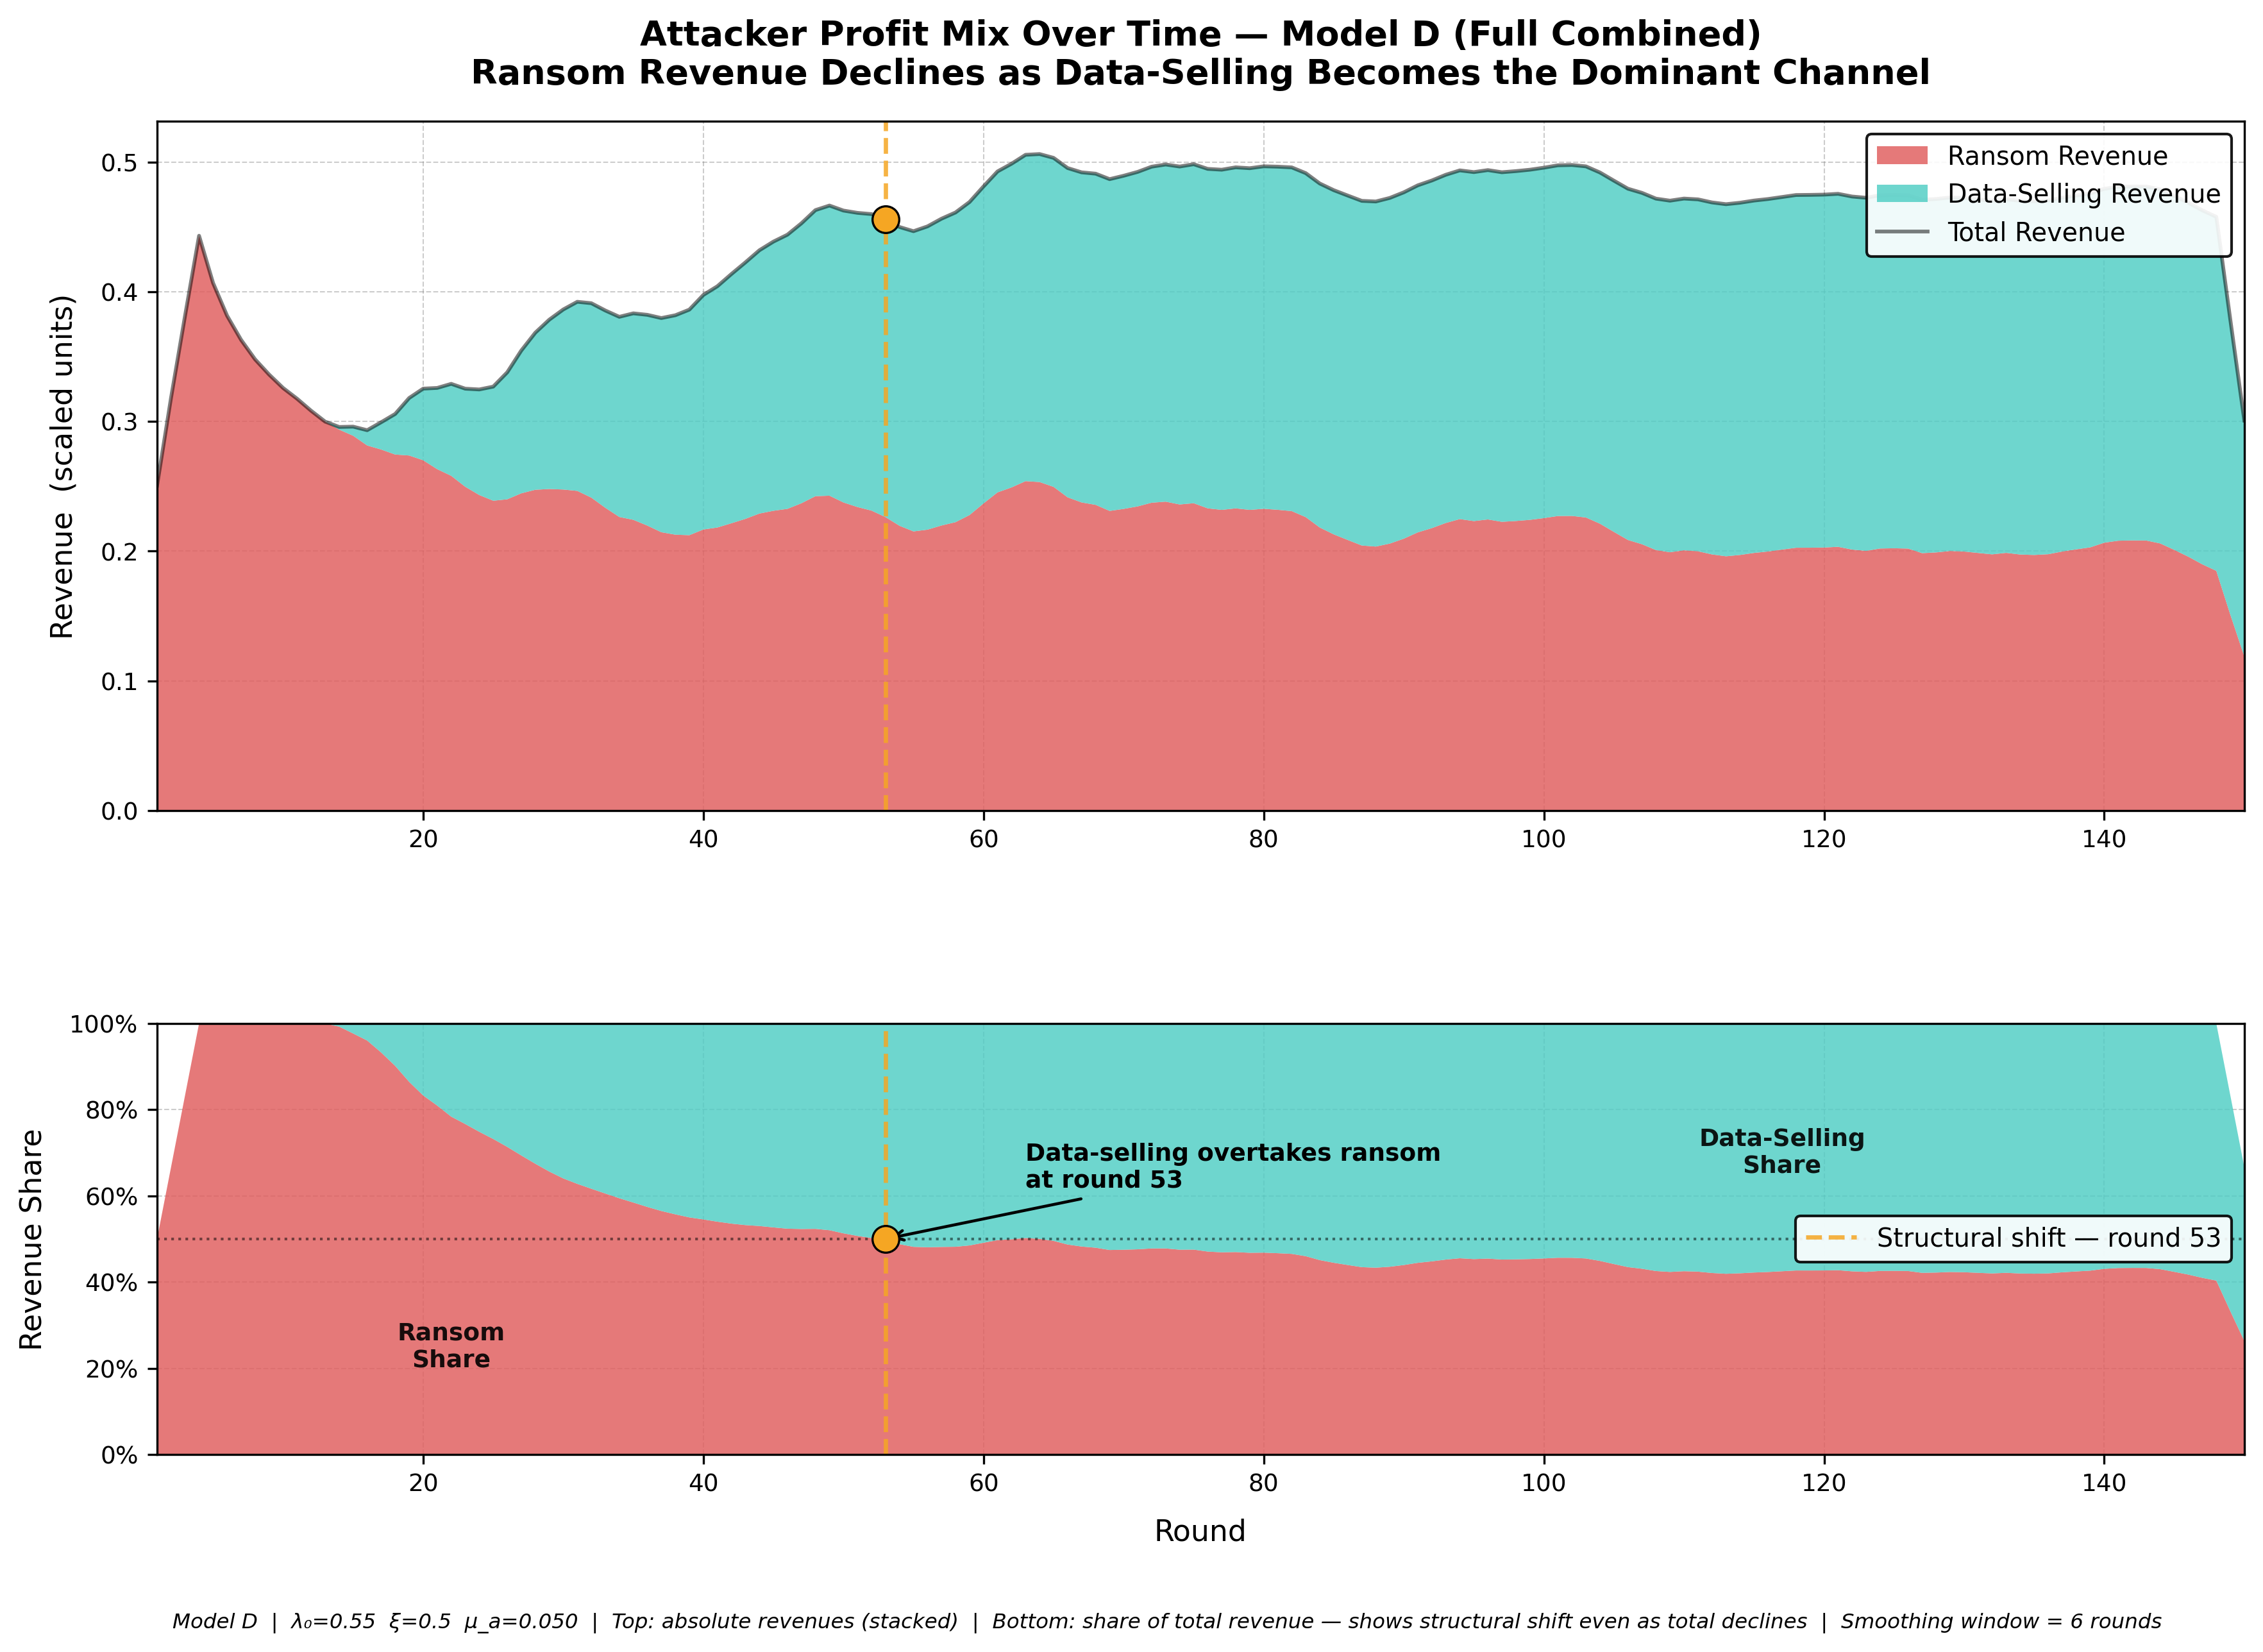

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

np.random.seed(42)

T       = 150
alpha   = 0.8; delta = 0.5; D0 = 5.0; CB0 = 1.0
eps0    = 0.28; kappa_eps = 0.10; kappa_b = 0.8
beta    = 0.9; F = 5.0; L = 32.0; CA = 1.5; CD = 3.0; G = 100
xi      = 0.5; beta_s = 0.7; M = 1.4; delta_e = 0.15
delta_f = 0.4; kappa_h = 0.08; Cs = 0.8

p = dict(mu_a=0.050, mu_n=0.026, lambda0=0.55, kl=0.22, MH=0.12, xi_v=xi)

def lr(Aa, An, t):
    return 1/(1+(Aa/max(An,1e-9))*t), 1/(1+(An/max(Aa,1e-9))*t)

def S(Aa):
    h = 1-(delta_f**0.5)/(1+kappa_h*Aa)
    return max(0,(1-delta_e)*h*M-Cs)

Aa = An = 1.0; sc = 0.0
rev_r_raw = []; rev_d_raw = []

for t in range(1, T+1):
    ra = np.random.uniform(-0.12, 0.12)
    rn = np.random.uniform(-0.12, 0.12)
    CBt = CB0/(1+delta*An); ba = np.sqrt(beta*F/max(CBt,1e-9))
    be  = eps0*(1+kappa_eps*Aa)/(1+kappa_b*ba)
    xiv = p['xi_v']; et = be*(1+p['MH']*xiv)
    sr  = sc/max(t,1); lam = min(p['lambda0']*sr/(1+p['kl']*Aa), 0.95)
    Psi = 1.0 - lam
    Dt  = D0/(1+alpha*Aa); CBt2 = CB0/(1+delta*An); St = S(Aa)
    eL  = (1-xiv)*L; b = max(np.sqrt(beta*(F+et*eL)/max(CBt2,1e-9)),1e-6)
    r   = et*eL/b
    rev_r_raw.append(Psi*r)
    rev_d_raw.append(beta_s*St)
    a   = max((G*Dt/CA)*(Psi*r+beta_s*St)-Dt, 0)
    Vj  = (a*(1+alpha*Aa))/(D0+a*(1+alpha*Aa)+1e-9)
    num = Psi*L*et*a*G; den = (Dt+a)*(CA*a+CD)+1e-9
    Phi = (num/den)*np.sqrt(CBt2/max(beta*F,1e-9))
    det = Phi < 1.0; sop = 0.0 if det else 1.0; fop = 1.0 - sop
    sc  = (sc*(t-1)+(Vj if not det else 0.0))/t
    ea, en = lr(Aa, An, t)
    Aa = Aa*(1+p['mu_a'])*(1+ea)*(1+ra*sop)
    An = An*(1+p['mu_n'])*(1+en)*(1+rn*fop)

rev_r = np.array(rev_r_raw)
rev_d = np.array(rev_d_raw)
total = rev_r + rev_d + 1e-9
share_r = rev_r / total
share_d = rev_d / total

w = 6
def sm(x): return np.convolve(x, np.ones(w)/w, mode='same')
rev_r_sm = sm(rev_r); rev_d_sm = sm(rev_d)
share_r_sm = sm(share_r); share_d_sm = sm(share_d)

crossover = None
for i in range(len(share_r_sm)-1):
    if share_d_sm[i] <= share_r_sm[i] and share_d_sm[i+1] > share_r_sm[i+1]:
        crossover = i + 2
        break

rounds = np.arange(1, T+1)
fig = plt.figure(figsize=(14, 9), dpi=300)
fig.patch.set_facecolor('white')
gs  = GridSpec(2, 1, figure=fig, hspace=0.38, height_ratios=[1.6, 1.0])

col_r = '#e05c5c'; col_d = '#4ecdc4'; col_cross = '#f5a623'; col_tot = 'black'

ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('white')
for sp in ax1.spines.values(): sp.set_edgecolor('black')
ax1.grid(color='gray', lw=0.5, ls='--', alpha=0.4); ax1.set_axisbelow(True)

ax1.stackplot(rounds, rev_r_sm, rev_d_sm,
              labels=['Ransom Revenue', 'Data-Selling Revenue'],
              colors=[col_r, col_d], alpha=0.82)
ax1.plot(rounds, rev_r_sm+rev_d_sm, color=col_tot, lw=1.4, alpha=0.5, label='Total Revenue')

if crossover:
    ax1.axvline(crossover, color=col_cross, lw=1.6, ls='--', alpha=0.85)
    ax1.scatter([crossover], [(rev_r_sm+rev_d_sm)[crossover-1]],
                color=col_cross, s=100, zorder=7, edgecolors='black', lw=0.8)

ax1.set_ylabel('Revenue  (scaled units)', color='black', fontsize=11, labelpad=8)
ax1.set_title('Attacker Profit Mix Over Time — Model D (Full Combined)\n'
              'Ransom Revenue Declines as Data-Selling Becomes the Dominant Channel',
              color='black', fontsize=13, fontweight='bold', pad=14)
ax1.tick_params(colors='black', labelsize=9)
ax1.legend(loc='upper right', framealpha=0.9, facecolor='white',
           edgecolor='black', labelcolor='black', fontsize=9.5)
ax1.set_xlim(1, T); ax1.set_ylim(bottom=0)

ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('white')
for sp in ax2.spines.values(): sp.set_edgecolor('black')
ax2.grid(color='gray', lw=0.5, ls='--', alpha=0.4); ax2.set_axisbelow(True)

ax2.stackplot(rounds, share_r_sm, share_d_sm,
              colors=[col_r, col_d], alpha=0.82)
ax2.axhline(0.5, color='black', lw=1.0, ls=':', alpha=0.5)

if crossover:
    ax2.axvline(crossover, color=col_cross, lw=1.6, ls='--', alpha=0.85,
                label=f'Structural shift — round {crossover}')
    ax2.scatter([crossover], [0.5], color=col_cross, s=100,
                zorder=7, edgecolors='black', lw=0.8)
    ax2.annotate(f'Data-selling overtakes ransom\nat round {crossover}',
                 xy=(crossover, 0.5), xytext=(crossover+10, 0.62),
                 color='black', fontsize=9, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.1))

ax2.text(int(T*0.15), 0.25, 'Ransom\nShare', color='black',
         fontsize=9, fontweight='bold', ha='center', va='center', alpha=0.9)
ax2.text(int(T*0.78), 0.70, 'Data-Selling\nShare', color='black',
         fontsize=9, fontweight='bold', ha='center', va='center', alpha=0.9)

ax2.set_xlabel('Round', color='black', fontsize=11, labelpad=8)
ax2.set_ylabel('Revenue Share', color='black', fontsize=11, labelpad=8)
ax2.tick_params(colors='black', labelsize=9)
ax2.set_xlim(1, T); ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
if crossover:
    ax2.legend(loc='center right', framealpha=0.9, facecolor='white',
               edgecolor='black', labelcolor='black', fontsize=9.5)

note = ('Model D  |  λ₀=0.55  ξ=0.5  μ_a=0.050  |  '
        'Top: absolute revenues (stacked)  |  '
        'Bottom: share of total revenue — shows structural shift even as total declines  |  '
        f'Smoothing window = {w} rounds')
fig.text(0.5, 0.01, note, ha='center', color='black', fontsize=7.8, style='italic')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

6. Sensitivity Surface

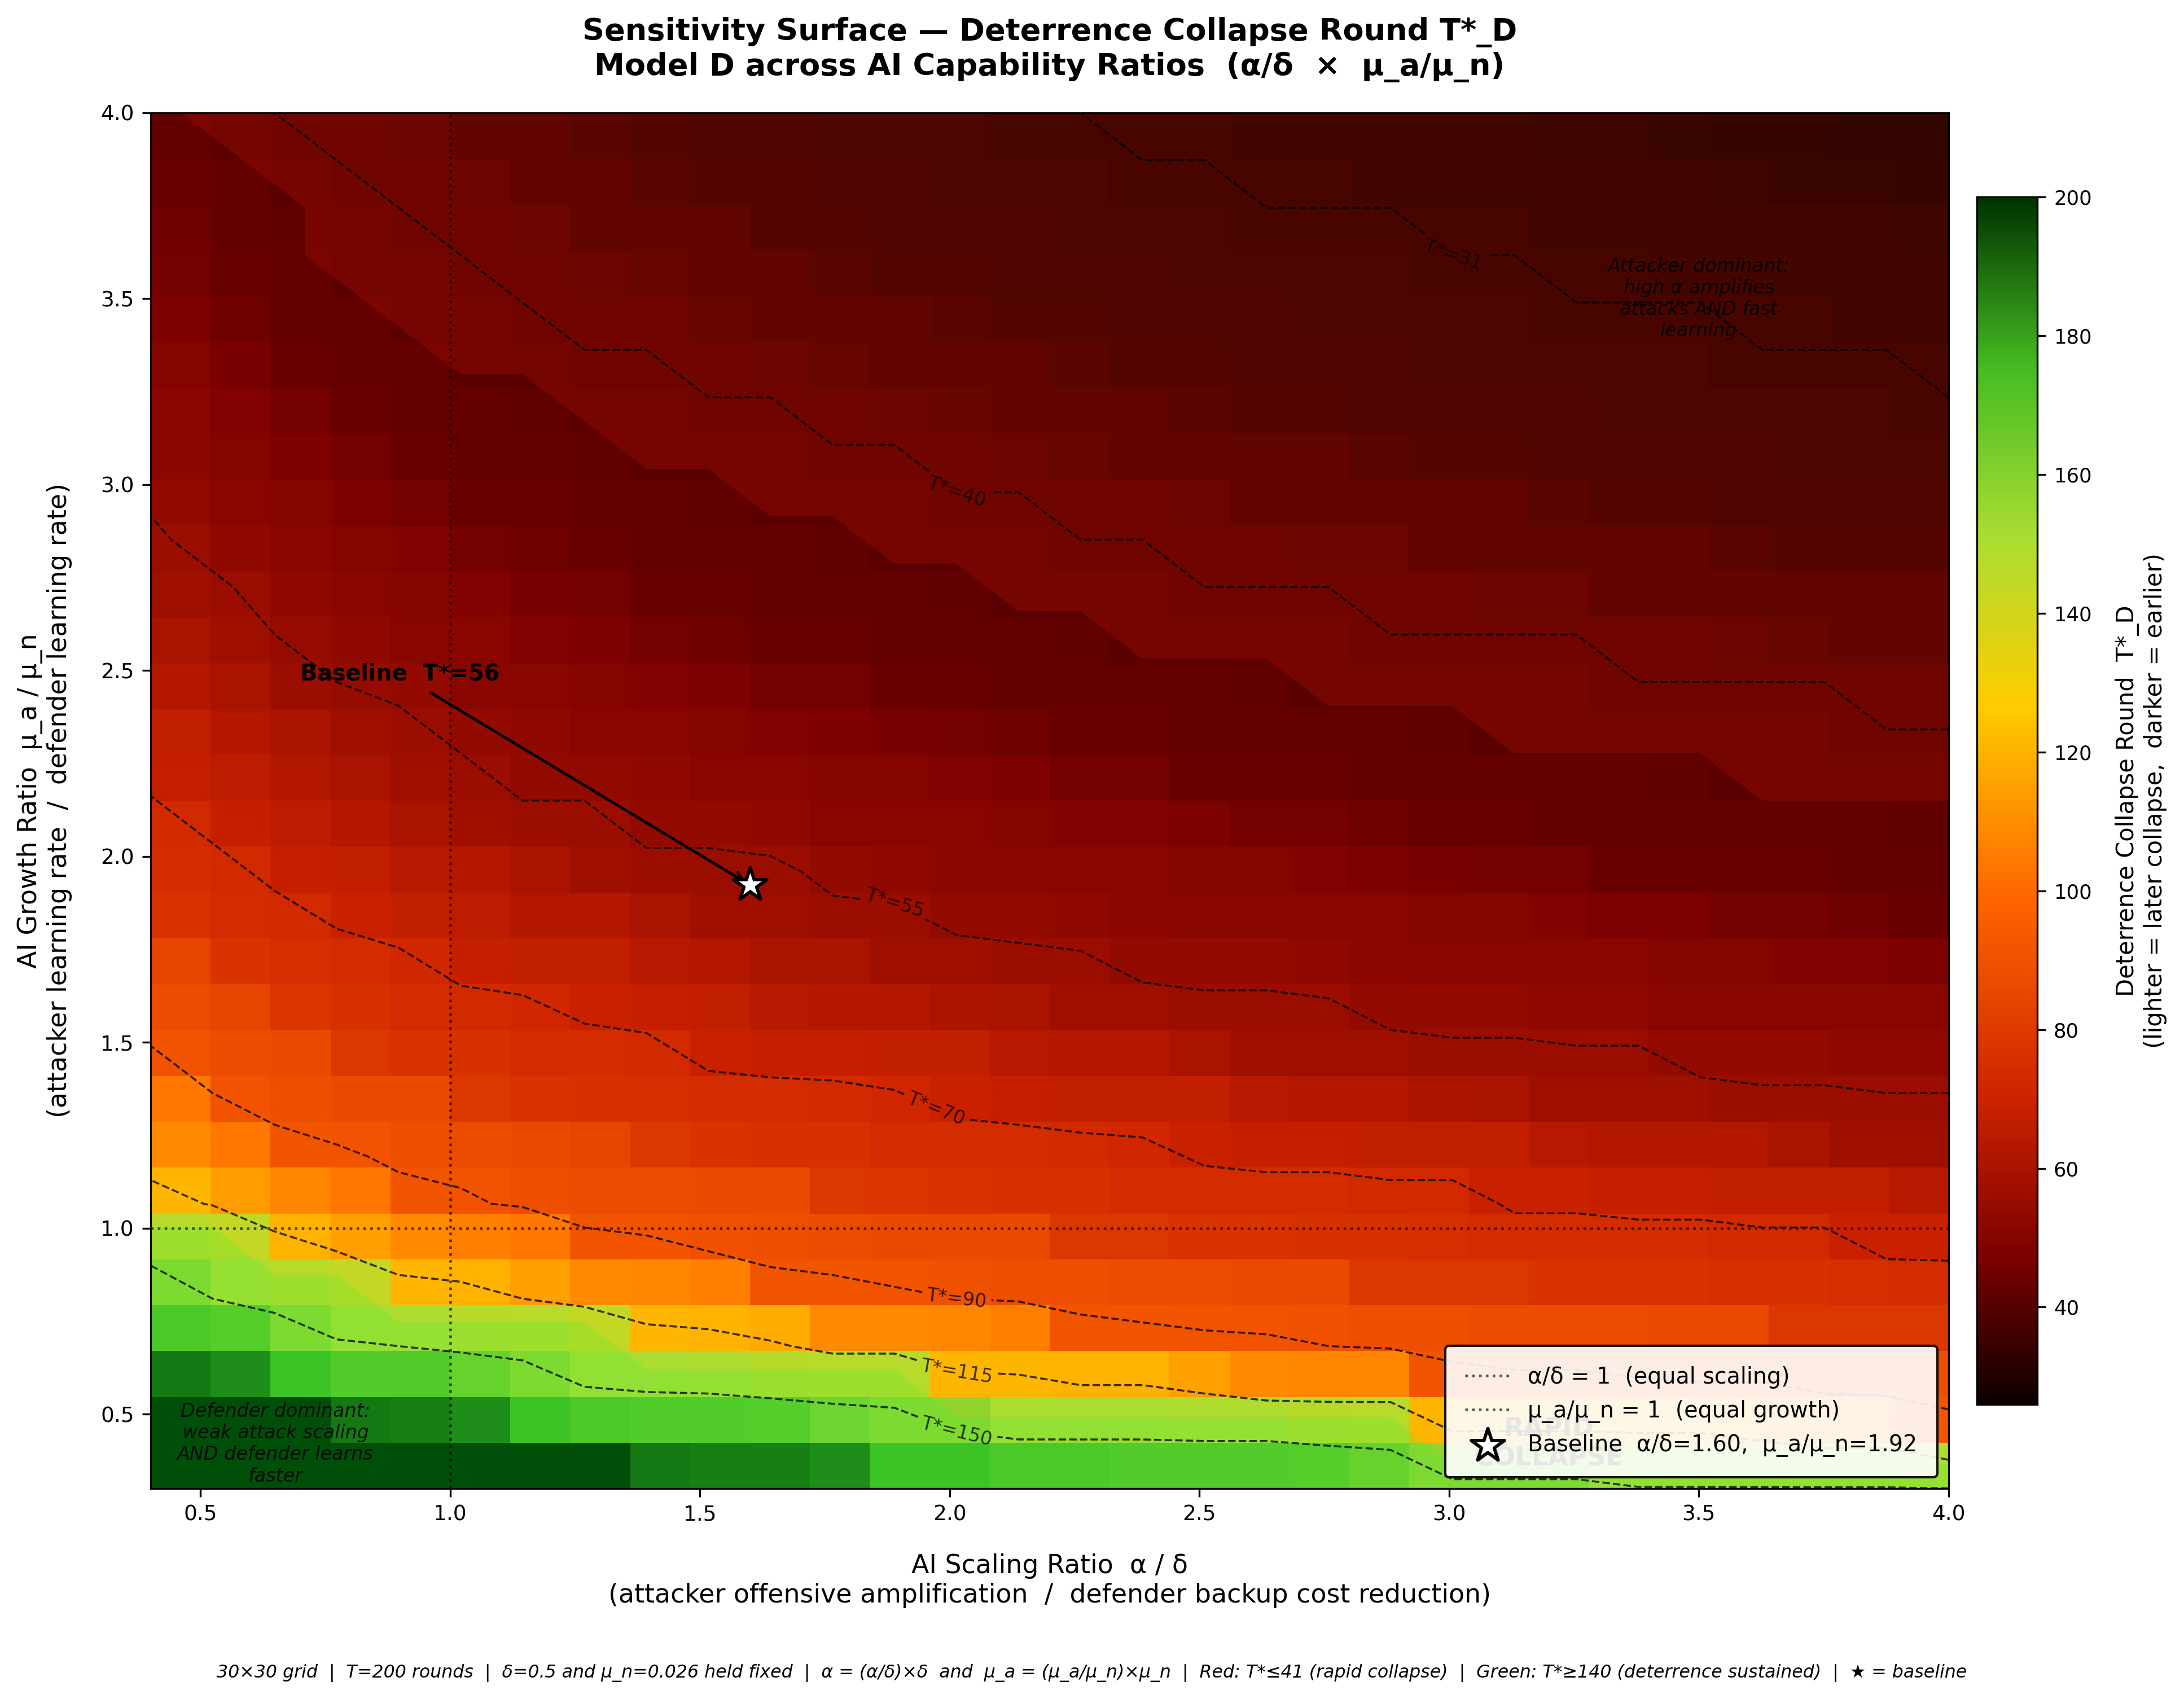

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(42)

T=200; D0=5.0; CB0=1.0; eps0=0.28; kappa_eps=0.10; kappa_b=0.8
beta=0.9; F=5.0; L=12.0; CA=1.5; CD=3.0; G=100; xi=0.5
beta_s=0.7; M=25.0; delta_e=0.15; delta_f=0.1; kappa_h=0.25; Cs=0.8
P_D = dict(lambda0=0.55, kl=0.22, MH=0.12, xi_v=xi)

BASE_ALPHA = 0.8
BASE_DELTA = 0.5
BASE_MUA   = 0.050
BASE_MUN   = 0.026

def lr(Aa,An,t):
    return 1/(1+(Aa/max(An,1e-9))*t), 1/(1+(An/max(Aa,1e-9))*t)

def S(Aa):
    h = 1-(delta_f**0.5)/(1+kappa_h*Aa)
    return max(0,(1-delta_e)*h*M-Cs)

def run(alpha, delta, mu_a, mu_n, seed=42):
    Aa=An=1.0; sc=0.0; np.random.seed(seed)
    for t in range(1,T+1):
        ra=np.random.uniform(-.12,.12); rn=np.random.uniform(-.12,.12)
        CBt=CB0/(1+delta*An); ba=np.sqrt(beta*F/max(CBt,1e-9))
        be=eps0*(1+kappa_eps*Aa)/(1+kappa_b*ba)
        xiv=P_D['xi_v']; et=be*(1+P_D['MH']*xiv)
        sr=sc/max(t,1); lam=min(P_D['lambda0']*sr/(1+P_D['kl']*Aa),.95); Psi=1-lam
        Dt=D0/(1+alpha*Aa); CBt2=CB0/(1+delta*An); St=S(Aa)
        eL=(1-xiv)*L; b=max(np.sqrt(beta*(F+et*eL)/max(CBt2,1e-9)),1e-6)
        r=et*eL/b; a=max((G*Dt/CA)*(Psi*r+beta_s*St)-Dt,0)
        Vj=(a*(1+alpha*Aa))/(D0+a*(1+alpha*Aa)+1e-9)
        num=Psi*L*et*a*G; den=(Dt+a)*(CA*a+CD)+1e-9
        Phi=(num/den)*np.sqrt(CBt2/max(beta*F,1e-9))
        if Phi>=1: return t
        det=Phi<1; sop=0 if det else 1; fop=1-sop
        sc=(sc*(t-1)+(Vj if not det else 0))/t
        ea,en=lr(Aa,An,t)
        Aa=Aa*(1+mu_a)*(1+ea)*(1+ra*sop)
        An=An*(1+mu_n)*(1+en)*(1+rn*fop)
    return T

N = 30

ad_ratios = np.linspace(0.4, 4.0, N)
mu_ratios = np.linspace(0.3, 4.0, N)

grid = np.zeros((N, N))
total = N*N; done = 0

for i, adr in enumerate(ad_ratios):
    for j, mur in enumerate(mu_ratios):
        alpha_v = adr * BASE_DELTA
        delta_v = BASE_DELTA
        mu_a_v  = mur * BASE_MUN
        mu_n_v  = BASE_MUN
        grid[i,j] = run(alpha_v, delta_v, mu_a_v, mu_n_v)
        done += 1

base_ad = BASE_ALPHA / BASE_DELTA
base_mu = BASE_MUA   / BASE_MUN

i_base = int(np.argmin(np.abs(ad_ratios - base_ad)))
j_base = int(np.argmin(np.abs(mu_ratios - base_mu)))

cmap = LinearSegmentedColormap.from_list('det', [
    (0.00, '#0d0000'),
    (0.12, '#7a0000'),
    (0.25, '#cc2200'),
    (0.42, '#ff6600'),
    (0.58, '#ffcc00'),
    (0.72, '#aadd33'),
    (0.86, '#44bb22'),
    (1.00, '#003300'),
], N=512)

fig, ax = plt.subplots(figsize=(13, 10), dpi=300)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
for sp in ax.spines.values(): sp.set_edgecolor('black')

im = ax.imshow(
    grid.T,
    origin='lower', aspect='auto', cmap=cmap,
    extent=[ad_ratios[0], ad_ratios[-1], mu_ratios[0], mu_ratios[-1]],
    vmin=grid.min(), vmax=T
)

contour_levels = sorted(set([
    int(grid.min())+5, 40, 55, 70, 90, 115, 150, T
]))
contour_levels = [c for c in contour_levels if grid.min() < c <= T]
cs = ax.contour(
    ad_ratios, mu_ratios, grid.T,
    levels=contour_levels,
    colors='black', linewidths=0.85, alpha=0.75, linestyles='--'
)
ax.clabel(cs, fmt='T*=%d', fontsize=8, colors='black',
          inline=True, inline_spacing=5)

FAST = int(grid.min()) + 15
SLOW = 140

ax.contourf(ad_ratios, mu_ratios, (grid.T <= FAST).astype(float),
            levels=[0.5,1.5], colors=['#ff2200'], alpha=0.16)
ax.contourf(ad_ratios, mu_ratios, (grid.T >= SLOW).astype(float),
            levels=[0.5,1.5], colors=['#00ff44'], alpha=0.14)

ax.axvline(1.0, color='black',   lw=1.1, ls=':', alpha=0.65,
           label='α/δ = 1  (equal scaling)')
ax.axhline(1.0, color='black', lw=1.1, ls=':', alpha=0.65,
           label='μ_a/μ_n = 1  (equal growth)')

ax.scatter([base_ad],[base_mu], color='white', s=220, zorder=9,
           marker='*', edgecolors='black', lw=1.4,
           label=f'Baseline  α/δ={base_ad:.2f},  μ_a/μ_n={base_mu:.2f}')
ax.annotate(f'Baseline  T*={int(grid[i_base, j_base])}',
            xy=(base_ad, base_mu),
            xytext=(base_ad - 0.9, base_mu + 0.55),
            color='black', fontsize=9.5, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2))

ax.text(3.2, 0.42, 'RAPID\nCOLLAPSE', color='black', fontsize=11,
        fontweight='bold', ha='center', va='center', alpha=0.95)

ax.text(3.5, 3.5,
        'Attacker dominant:\nhigh α amplifies\nattacks AND fast\nlearning',
        color='black', fontsize=8, ha='center', va='center',
        alpha=0.85, style='italic')
ax.text(0.65, 0.42,
        'Defender dominant:\nweak attack scaling\nAND defender learns\nfaster',
        color='black', fontsize=8, ha='center', va='center',
        alpha=0.85, style='italic')

cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.032)
cbar.set_label('Deterrence Collapse Round  T*_D\n(lighter = later collapse,  darker = earlier)',
               color='black', fontsize=10, labelpad=10)
cbar.ax.yaxis.set_tick_params(color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black', fontsize=8.5)
cbar.ax.set_facecolor('white')

ax.set_xlabel('AI Scaling Ratio  α / δ\n(attacker offensive amplification  /  defender backup cost reduction)',
              color='black', fontsize=11, labelpad=12)
ax.set_ylabel('AI Growth Ratio  μ_a / μ_n\n(attacker learning rate  /  defender learning rate)',
              color='black', fontsize=11, labelpad=12)
ax.set_title(
    'Sensitivity Surface — Deterrence Collapse Round T*_D\n'
    'Model D across AI Capability Ratios  (α/δ  ×  μ_a/μ_n)',
    color='black', fontsize=13, fontweight='bold', pad=16
)
ax.tick_params(colors='black', labelsize=9)
ax.legend(loc='lower right', framealpha=0.9, facecolor='white',
          edgecolor='black', labelcolor='black', fontsize=9.5, borderpad=0.9)

note = (f'{N}×{N} grid  |  T={T} rounds  |  δ={BASE_DELTA} and μ_n={BASE_MUN} held fixed  |  '
        f'α = (α/δ)×δ  and  μ_a = (μ_a/μ_n)×μ_n  |  '
        f'Red: T*≤{FAST} (rapid collapse)  |  Green: T*≥{SLOW} (deterrence sustained)  |  ★ = baseline')
fig.text(0.5, 0.004, note, ha='center', color='black', fontsize=7.6, style='italic')

plt.tight_layout(rect=[0,0.03,1,1])
plt.show()

5. Cumulative Welfare

Model A: total_def=103033  ransom=1451  att_net=179332  det_rounds=53  T*=54
Model B: total_def=102500  ransom=961  att_net=181608  det_rounds=52  T*=51
Model C: total_def=102884  ransom=1321  att_net=191363  det_rounds=64  T*=63
Model D: total_def=102279  ransom=868  att_net=184466  det_rounds=55  T*=56


/tmp/ipykernel_4167/500231785.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 1])


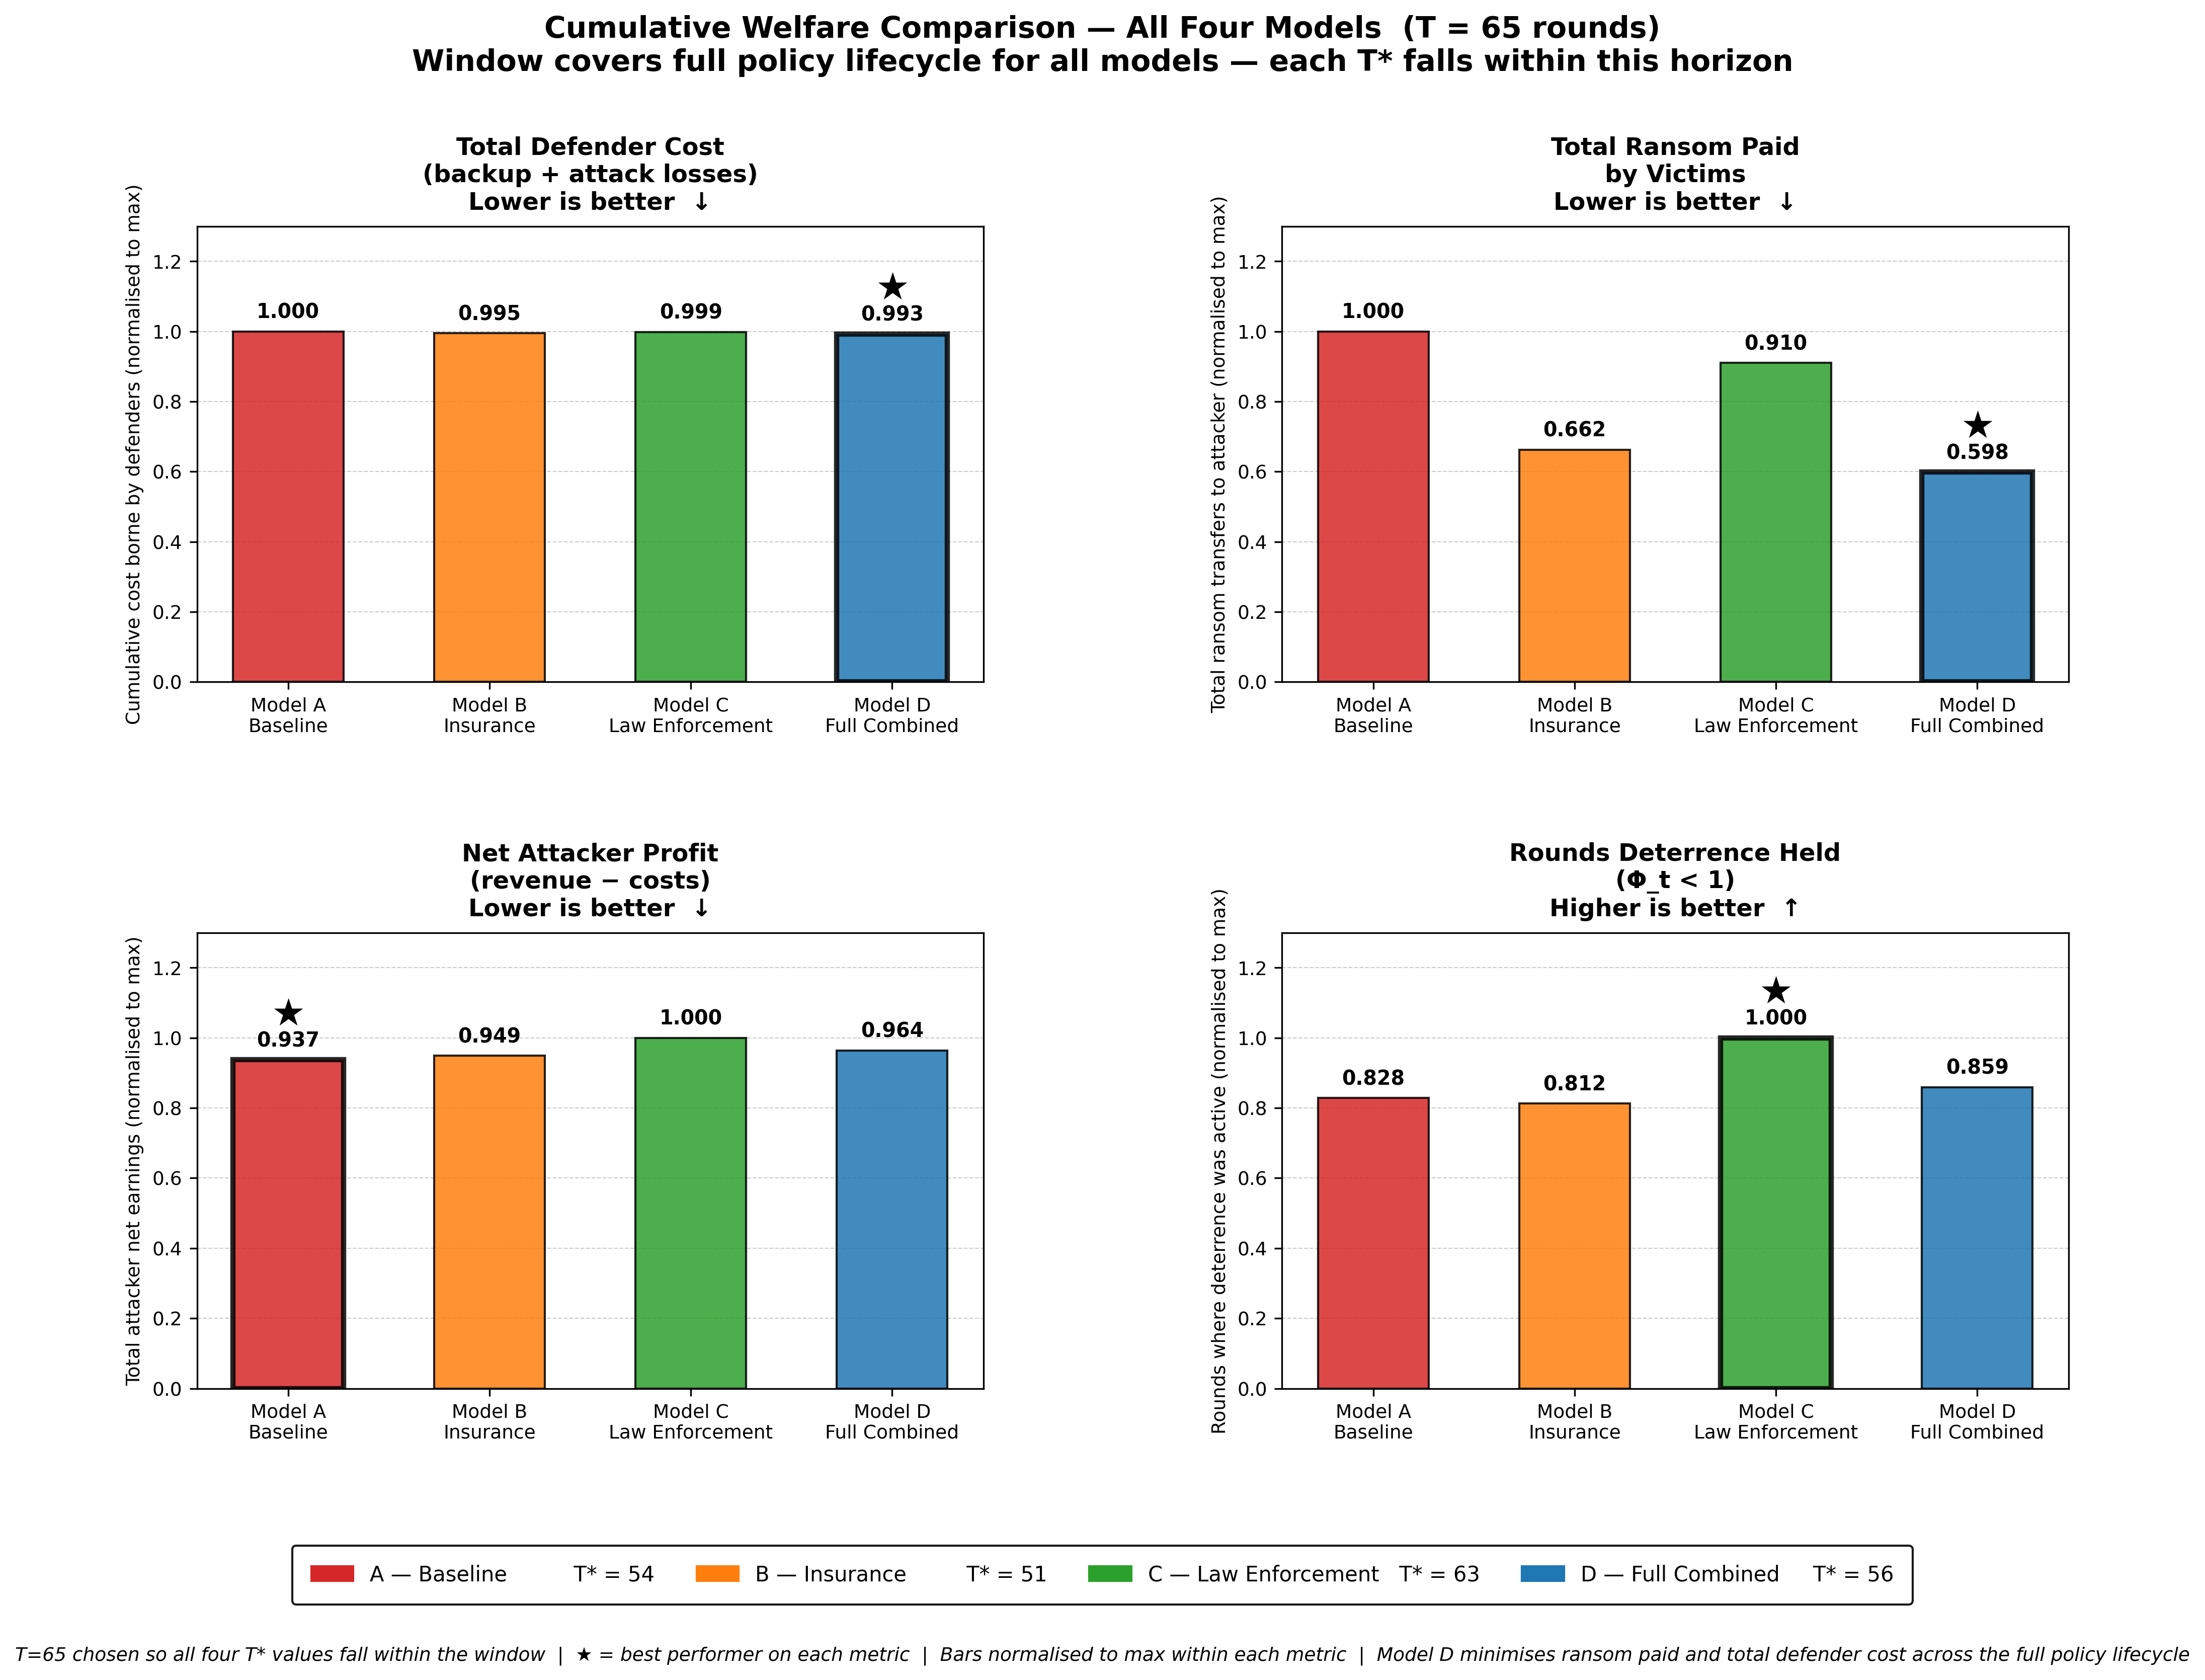

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

np.random.seed(42)

T=65; alpha=0.8; delta=0.5; D0=5.0; CB0=1.0
eps0=0.28; kappa_eps=0.10; kappa_b=0.8; beta=0.9; F=5.0; L=12.0
CA=1.5; CD=3.0; G=100; xi=0.5; beta_s=0.7; M=25.0
delta_e=0.15; delta_f=0.1; kappa_h=0.25; Cs=0.8; T_loss=15.0

params = {
    'A': dict(mu_a=0.055, mu_n=0.030, lambda0=0.0,  kl=0.25, MH=0.0,  xi_v=0.0),
    'B': dict(mu_a=0.055, mu_n=0.020, lambda0=0.0,  kl=0.25, MH=0.25, xi_v=xi),
    'C': dict(mu_a=0.044, mu_n=0.033, lambda0=0.65, kl=0.20, MH=0.0,  xi_v=0.0),
    'D': dict(mu_a=0.050, mu_n=0.026, lambda0=0.55, kl=0.22, MH=0.12, xi_v=xi),
}

def lr(Aa, An, t):
    return 1/(1+(Aa/max(An,1e-9))*t), 1/(1+(An/max(Aa,1e-9))*t)

def S(Aa):
    h = 1-(delta_f**0.5)/(1+kappa_h*Aa)
    return max(0,(1-delta_e)*h*M-Cs)

def run(mode, seed=42):
    p=params[mode]; Aa=An=1.0; sc=0.0
    phi_path=[]
    cum_backup=0.0; cum_ransom=0.0; cum_data_rev=0.0
    cum_att_cost=0.0; cum_def_attack_loss=0.0; rounds_deterred=0
    np.random.seed(seed)

    for t in range(1, T+1):
        ra=np.random.uniform(-0.12, 0.12)
        rn=np.random.uniform(-0.12, 0.12)
        CBt=CB0/(1+delta*An); ba=np.sqrt(beta*F/max(CBt,1e-9))
        be=eps0*(1+kappa_eps*Aa)/(1+kappa_b*ba)
        xiv=p['xi_v']; et=be*(1+p['MH']*xiv)
        Psi=1.0
        if p['lambda0']>0:
            sr=sc/max(t,1)
            lam=min(p['lambda0']*sr/(1+p['kl']*Aa), 0.95)
            Psi=1.0-lam
        Dt=D0/(1+alpha*Aa); CBt2=CB0/(1+delta*An); St=S(Aa)
        eL=(1-xiv)*L; b=max(np.sqrt(beta*(F+et*eL)/max(CBt2,1e-9)),1e-6)
        r=et*eL/b
        a=max((G*Dt/CA)*(Psi*r+beta_s*St)-Dt, 0)
        Vj=(a*(1+alpha*Aa))/(D0+a*(1+alpha*Aa)+1e-9)
        num=Psi*L*et*a*G; den=(Dt+a)*(CA*a+CD)+1e-9
        Phi=(num/den)*np.sqrt(CBt2/max(beta*F,1e-9))
        phi_path.append(Phi)

        pay_ransom = r <= eL/b
        r_paid     = r if pay_ransom else 0.0
        data_rev   = beta_s*St*a*Vj
        att_cost   = CA*a+(CD if a>0 else 0)

        cum_backup          += CBt2*b*G
        cum_ransom          += Psi*r_paid*Vj*G
        cum_data_rev        += data_rev
        cum_att_cost        += att_cost
        cum_def_attack_loss += Vj*(T_loss+r_paid)*G

        det=Phi<1.0
        if det: rounds_deterred+=1
        sop=0.0 if det else 1.0; fop=1.0-sop
        sc=(sc*(t-1)+(Vj if not det else 0.0))/t
        ea,en=lr(Aa,An,t)
        Aa=Aa*(1+p['mu_a'])*(1+ea)*(1+ra*sop)
        An=An*(1+p['mu_n'])*(1+en)*(1+rn*fop)

    t_star=next((i+1 for i,v in enumerate(phi_path) if v>=1), T)
    return dict(
        backup=cum_backup,
        ransom_paid=cum_ransom,
        def_attack_loss=cum_def_attack_loss,
        total_def_cost=cum_backup+cum_def_attack_loss,
        att_net_profit=cum_ransom+cum_data_rev-cum_att_cost,
        rounds_deterred=rounds_deterred,
        t_star=t_star,
    )

results = {m: run(m) for m in 'ABCD'}

for m in 'ABCD':
    r=results[m]
    print(f"Model {m}: total_def={r['total_def_cost']:.0f}  ransom={r['ransom_paid']:.0f}  "
          f"att_net={r['att_net_profit']:.0f}  det_rounds={r['rounds_deterred']}  T*={r['t_star']}")

models  = list('ABCD')
labels  = ['Model A\nBaseline', 'Model B\nInsurance',
           'Model C\nLaw Enforcement', 'Model D\nFull Combined']
x       = np.arange(4)

def rng(arr):
    return arr / arr.max()

total_def_n  = rng(np.array([results[m]['total_def_cost']   for m in models]))
ransom_n     = rng(np.array([results[m]['ransom_paid']      for m in models]))
att_profit_n = rng(np.array([results[m]['att_net_profit']    for m in models]))
det_rounds_n = rng(np.array([results[m]['rounds_deterred']   for m in models]))
t_stars      = [results[m]['t_star'] for m in models]

col_A='#d62728'; col_B='#ff7f0e'; col_C='#2ca02c'; col_D='#1f77b4'
model_colors = [col_A, col_B, col_C, col_D]

fig = plt.figure(figsize=(16, 10), dpi=300)
fig.patch.set_facecolor('white')
gs  = GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.38)
axes = [fig.add_subplot(gs[r,c]) for r in range(2) for c in range(2)]

metrics = [
    (total_def_n,  'Total Defender Cost\n(backup + attack losses)',
     'Lower is better  ↓',  True,
     'Cumulative cost borne by defenders (normalised to max)'),
    (ransom_n,     'Total Ransom Paid\nby Victims',
     'Lower is better  ↓',  True,
     'Total ransom transfers to attacker (normalised to max)'),
    (att_profit_n, 'Net Attacker Profit\n(revenue − costs)',
     'Lower is better  ↓',  True,
     'Total attacker net earnings (normalised to max)'),
    (det_rounds_n, 'Rounds Deterrence Held\n(Φ_t < 1)',
     'Higher is better  ↑',  False,
     'Rounds where deterrence was active (normalised to max)'),
]

for ax, (vals, title, direction, lower_better, ylab) in zip(axes, metrics):
    ax.set_facecolor('white')
    for sp in ax.spines.values(): sp.set_edgecolor('black')
    ax.grid(axis='y', color='gray', lw=0.5, ls='--', alpha=0.4)
    ax.set_axisbelow(True)

    best_idx = int(np.argmin(vals)) if lower_better else int(np.argmax(vals))

    bars = ax.bar(x, vals, width=0.55, color=model_colors,
                  alpha=0.85, edgecolor='black', linewidth=1.0)

    for i, (bar, val) in enumerate(zip(bars, vals)):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.025,
                f'{val:.3f}', ha='center', va='bottom',
                color='black', fontsize=9.5, fontweight='bold')

    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)
    ax.text(x[best_idx], vals[best_idx]+0.10,
            '★', ha='center', color='black', fontsize=18)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, color='black', fontsize=10)
    ax.set_ylabel(ylab, color='black', fontsize=9)
    ax.set_title(f'{title}\n{direction}',
                 color='black', fontsize=11.5, fontweight='bold', pad=8)
    ax.tick_params(colors='black', labelsize=9)
    ax.set_ylim(0, 1.30)

fig.suptitle(
    f'Cumulative Welfare Comparison — All Four Models  (T = {T} rounds)\n'
    'Window covers full policy lifecycle for all models — each T* falls within this horizon',
    color='black', fontsize=14, fontweight='bold', y=1.02
)

patch_A = mpatches.Patch(color=col_A, label=f'A — Baseline          T* = {t_stars[0]}')
patch_B = mpatches.Patch(color=col_B, label=f'B — Insurance         T* = {t_stars[1]}')
patch_C = mpatches.Patch(color=col_C, label=f'C — Law Enforcement   T* = {t_stars[2]}')
patch_D = mpatches.Patch(color=col_D, label=f'D — Full Combined     T* = {t_stars[3]}')
fig.legend(handles=[patch_A,patch_B,patch_C,patch_D],
           loc='lower center', ncol=4, framealpha=0.9,
           facecolor='white', edgecolor='black',
           labelcolor='black', fontsize=10, borderpad=0.9,
           bbox_to_anchor=(0.5, -0.04))

note = (f'T={T} chosen so all four T* values fall within the window  |  '
        f'★ = best performer on each metric  |  '
        f'Bars normalised to max within each metric  |  '
        f'Model D minimises ransom paid and total defender cost across the full policy lifecycle')
fig.text(0.5, -0.07, note, ha='center', color='black', fontsize=9, style='italic')

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()